In [4]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *
from plots import *
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
data = load_data()

In [ ]:
data.head()

In [ ]:
target = 't_seasdiff'
exog=['lagged_tmed', 'lagged_prec', 'lagged_tmin', 'lagged_tmax']

In [8]:
data.head()

,date,tmax,tmin,tmed,month,year,prec,tdiff,log_diff,lagged_tdiff,lagged_prec,lagged_tmed,lagged_tmax,lagged_tmin
date,,,,,,,,,,,,,,
1995-01-01,1995-01-01,13.86,5.67,9.77,1,1995,144.1,8.19,2.102914,NaN,NaN,NaN,NaN,NaN
1995-02-01,1995-02-01,15.12,6.62,10.87,2,1995,92.8,8.50,2.140066,8.19,144.1,9.77,13.86,5.67
1995-03-01,1995-03-01,18.09,7.00,12.54,3,1995,31.3,11.09,2.406044,8.50,92.8,10.87,15.12,6.62
1995-04-01,1995-04-01,21.59,8.63,15.11,4,1995,30.5,12.96,2.561868,11.09,31.3,12.54,18.09,7.00
1995-05-01,1995-05-01,23.35,12.32,17.84,5,1995,51.4,11.03,2.400619,12.96,30.5,15.11,21.59,8.63


In [9]:
if target == 't_seasdiff':
    data["t_seasdiff"]= data["tdiff"].diff(12)
    data = data.dropna(subset=["t_seasdiff"])

# SARIMA / SARIMAX

In [10]:
len(data)

289

In [11]:
p, d, q = 0, 1, 1
P, D, Q, s = 1, 0, 0, 12


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

def _plot_cv_results(df, target, split_metrics, forecasts, actuals, 
                     train_months, forecast_months):
    """Helper function to visualize cross-validation results."""
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: All data with CV splits highlighted
    ax1 = axes[0]
    ax1.plot(df.index, df[target], label='Full Data', alpha=0.7, color='blue')
    
    for i, split_info in enumerate(split_metrics):
        test_start = split_info['test_start']
        test_end = split_info['test_end']
        ax1.axvspan(test_start, test_end, alpha=0.2, color='red', 
                   label='Test Period' if i == 0 else '')
        ax1.axvline(split_info['train_end'], color='green', linestyle='--', 
                   alpha=0.5, label='Train End' if i == 0 else '')
    
    ax1.set_title(f'Time Series with CV Splits ({train_months//12}yr train, {forecast_months}mo forecast)')
    ax1.set_xlabel('Date')
    ax1.set_ylabel(target)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Forecast vs Actual for test periods
    ax2 = axes[1]
    
    # Reconstruct index for forecasts
    forecast_indices = []
    for split_info in split_metrics:
        test_start = split_info['test_start']
        test_end = split_info['test_end']
        indices = df.loc[test_start:test_end].index
        forecast_indices.extend(indices[:forecast_months])
    
    ax2.plot(forecast_indices, actuals, label='Actual', marker='o', 
            markersize=3, linewidth=1.5)
    ax2.plot(forecast_indices, forecasts, label='Forecast', marker='x', 
            markersize=3, linewidth=1.5, alpha=0.7)
    
    ax2.set_title('Forecast vs Actual (SARIMAX)')
    ax2.set_xlabel('Date')
    ax2.set_ylabel(target)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Plot metrics over splits
    metrics_df = pd.DataFrame(split_metrics)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(metrics_df['split'], metrics_df['rmse'], marker='o', label='RMSE')
    ax.plot(metrics_df['split'], metrics_df['mae'], marker='s', label='MAE')
    ax.set_xlabel('Split Number')
    ax.set_ylabel('Error')
    ax.set_title('Forecast Errors Across CV Splits')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def sarimax_time_series_cv(df, target, p, d, q, P, D, Q, s, 
                           train_years=9, forecast_months=12, 
                           test_start_year=2010, exog=None):
    """
    Perform time series cross-validation for SARIMAX models.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with datetime index
    target : str
        Name of target column
    p, d, q : int
        Non-seasonal ARIMA parameters
    P, D, Q, s : int
        Seasonal ARIMA parameters
    train_years : int
        Number of years to use for training (default: 9)
    forecast_months : int
        Number of months to forecast ahead (default: 12)
    test_start_year : int
        Year to start testing from (default: 2010)
    exog : list of str, optional
        Names of exogenous variables
        
    Returns:
    --------
    dict : Dictionary containing results and metrics
    """
    
    # Calculate number of splits based on available test data
    test_data = df[df.index.year >= test_start_year]
    total_test_months = len(test_data)
    train_months = train_years * 12
    
    # Calculate splits: we can make a prediction every forecast_months
    n_splits = (total_test_months - train_months) // forecast_months
    
    print(f"Data range: {df.index.min().year} to {df.index.max().year}")
    print(f"Training window: {train_years} years ({train_months} months)")
    print(f"Forecast horizon: {forecast_months} months")
    print(f"Testing period: {test_start_year} onwards")
    print(f"Number of CV splits: {n_splits}\n")
    
    # Initialize storage for results
    all_forecasts = []
    all_actuals = []
    all_train_ends = []
    split_metrics = []
    
    # Perform time series cross-validation
    for split_idx in range(n_splits):
        # Calculate train/test indices
        train_start_idx = (test_start_year - df.index.min().year) * 12 + split_idx * forecast_months
        train_end_idx = train_start_idx + train_months
        test_end_idx = train_end_idx + forecast_months
        
        # Extract train and test data
        train = df[target].iloc[train_start_idx:train_end_idx]
        test = df[target].iloc[train_end_idx:test_end_idx]
        
        # Handle exogenous variables
        exog_train = exog_test = None
        if exog is not None:
            exog_train = df[exog].iloc[train_start_idx:train_end_idx]
            exog_test = df[exog].iloc[train_end_idx:test_end_idx]
        
        # Fit model
        try:
            model = SARIMAX(train, exog=exog_train, 
                          order=(p, d, q), 
                          seasonal_order=(P, D, Q, s))
            results = model.fit(disp=False)
            
            # Forecast
            forecast = results.forecast(steps=forecast_months, exog=exog_test)
            
            # Calculate metrics for this split
            rmse = np.sqrt(mean_squared_error(test, forecast))
            mae = mean_absolute_error(test, forecast)
            
            # Store results
            all_forecasts.extend(forecast.values)
            all_actuals.extend(test.values)
            all_train_ends.append(train.index[-1])
            split_metrics.append({
                'split': split_idx + 1,
                'train_end': train.index[-1],
                'test_start': test.index[0],
                'test_end': test.index[-1],
                'rmse': rmse,
                'mae': mae
            })
            
            print(f"Split {split_idx + 1}/{n_splits} - "
                  f"Train: {train.index[0].strftime('%Y-%m')} to {train.index[-1].strftime('%Y-%m')}, "
                  f"Test: {test.index[0].strftime('%Y-%m')} to {test.index[-1].strftime('%Y-%m')} - "
                  f"RMSE: {rmse:.4f}, MAE: {mae:.4f}")
            
        except Exception as e:
            print(f"Split {split_idx + 1} failed: {str(e)}")
            continue
    
    # Calculate overall metrics
    overall_rmse = np.sqrt(mean_squared_error(all_actuals, all_forecasts))
    overall_mae = mean_absolute_error(all_actuals, all_forecasts)
    avg_rmse = np.mean([m['rmse'] for m in split_metrics])
    avg_mae = np.mean([m['mae'] for m in split_metrics])
    
    print(f"\n{'='*70}")
    print(f"OVERALL METRICS (concatenated predictions):")
    print(f"RMSE: {overall_rmse:.4f}")
    print(f"MAE: {overall_mae:.4f}")
    print(f"\nAVERAGE METRICS (across splits):")
    print(f"Average RMSE: {avg_rmse:.4f}")
    print(f"Average MAE: {avg_mae:.4f}")
    print(f"{'='*70}\n")
    
    # Visualize results
    _plot_cv_results(df, target, split_metrics, all_forecasts, all_actuals, 
                     train_months, forecast_months)
    
    return {
        'split_metrics': pd.DataFrame(split_metrics),
        'overall_rmse': overall_rmse,
        'overall_mae': overall_mae,
        'avg_rmse': avg_rmse,
        'avg_mae': avg_mae,
        'forecasts': all_forecasts,
        'actuals': all_actuals
    }


Data range: 1996 to 2020
Training window: 9 years (108 months)
Forecast horizon: 12 months
Testing period: 1995 onwards
Number of CV splits: 15

Split 1 failed: zero-size array to reduction operation maximum which has no identity
Split 2/15 - Train: 1996-01 to 2004-12, Test: 2005-01 to 2005-12 - RMSE: 2.2387, MAE: 1.8520
Split 3/15 - Train: 1997-01 to 2005-12, Test: 2006-01 to 2006-12 - RMSE: 1.4541, MAE: 1.2077
Split 4/15 - Train: 1998-01 to 2006-12, Test: 2007-01 to 2007-12 - RMSE: 1.6346, MAE: 1.4073
Split 5/15 - Train: 1999-01 to 2007-12, Test: 2008-01 to 2008-12 - RMSE: 1.1437, MAE: 0.9225
Split 6/15 - Train: 2000-01 to 2008-12, Test: 2009-01 to 2009-12 - RMSE: 3.0736, MAE: 2.7817
Split 7/15 - Train: 2001-01 to 2009-12, Test: 2010-01 to 2010-12 - RMSE: 1.1609, MAE: 0.9781
Split 8/15 - Train: 2002-01 to 2010-12, Test: 2011-01 to 2011-12 - RMSE: 1.4213, MAE: 1.1059
Split 9/15 - Train: 2003-01 to 2011-12, Test: 2012-01 to 2012-12 - RMSE: 1.8202, MAE: 1.5141
Split 10/15 - Train: 2004-

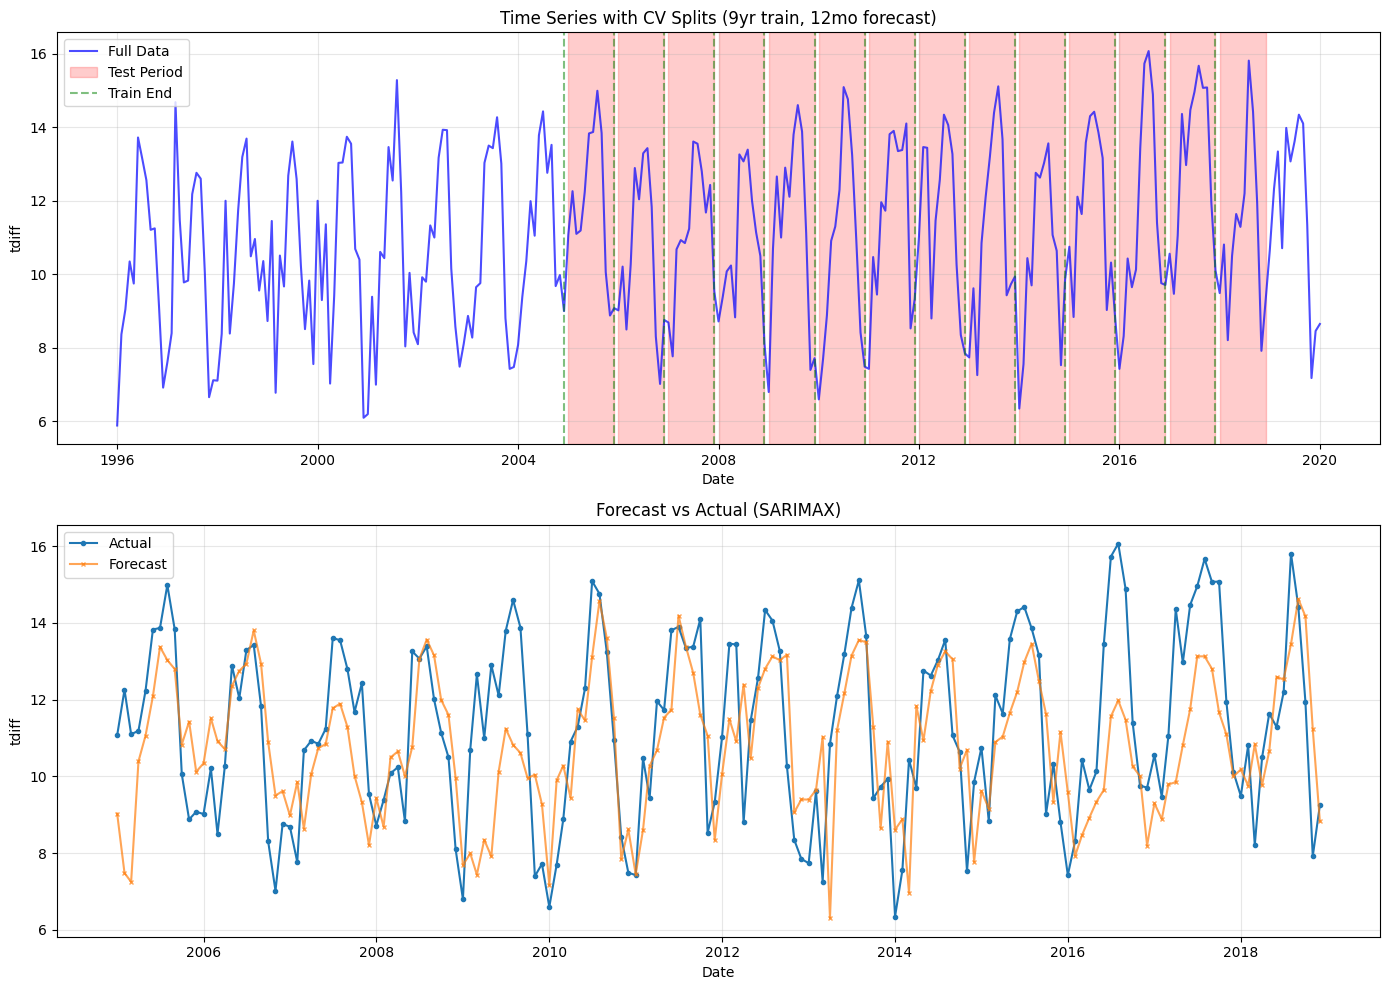

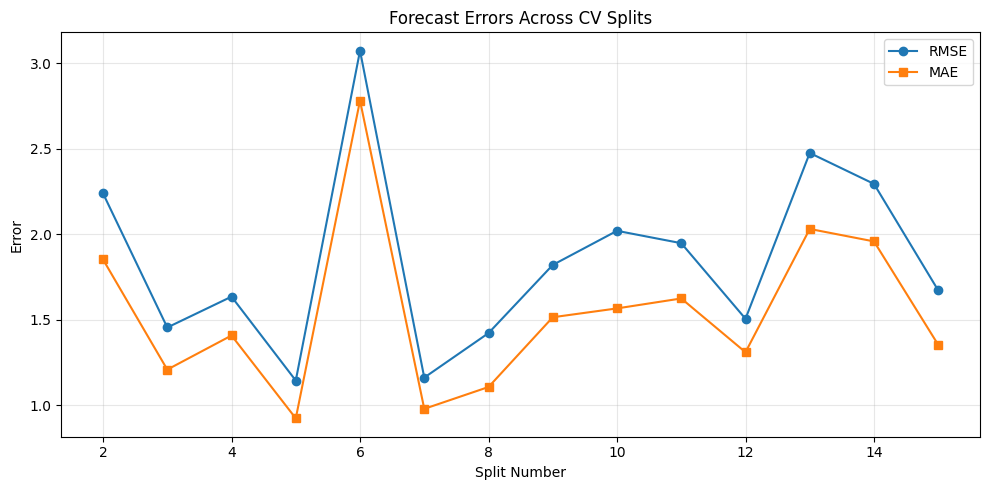

In [13]:
results = sarimax_time_series_cv(data, 'tdiff', p, d, q, P, D, Q, s, test_start_year=1995, exog=['lagged_prec', 'lagged_tmin', 'lagged_tmax', 'lagged_tmed'])

In [14]:
rmse, mae, results, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s)

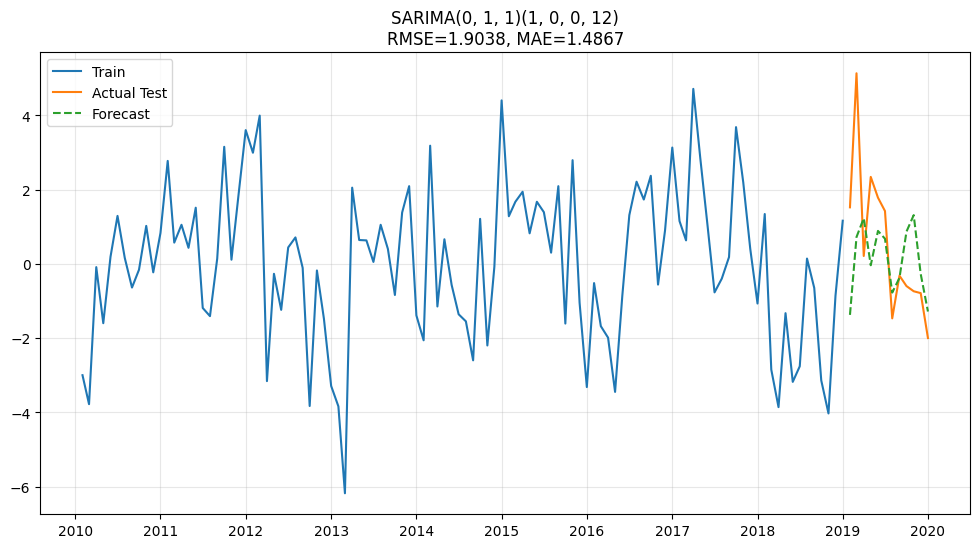

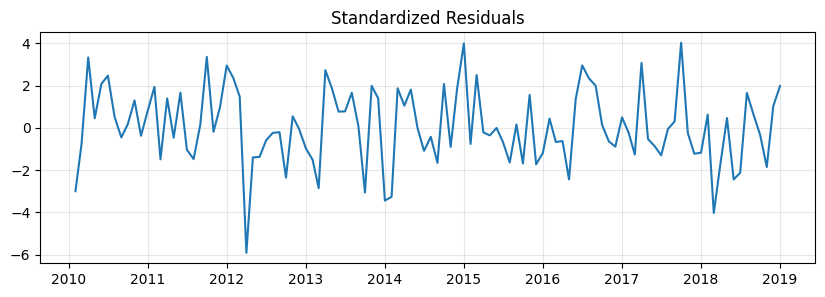

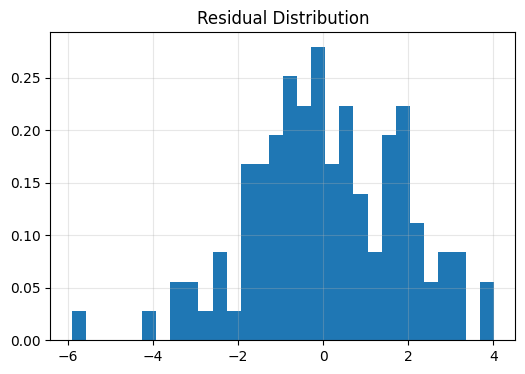

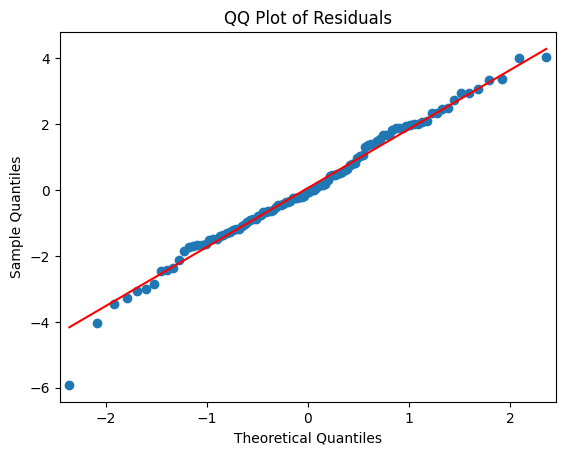

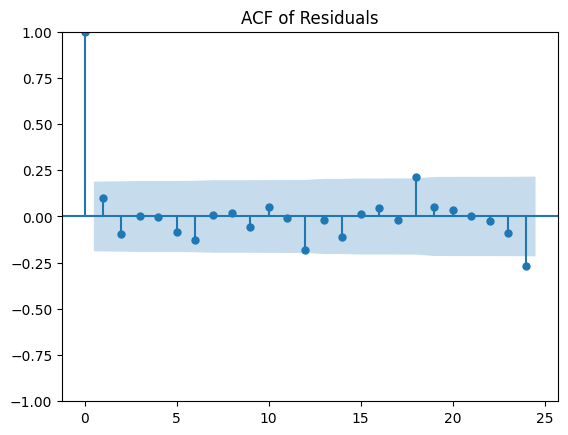

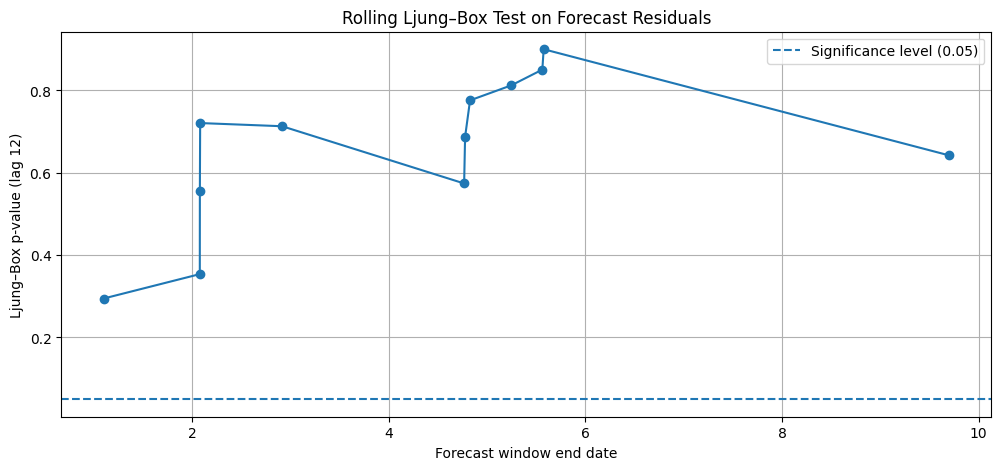

In [15]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=(p,d,q),
    seasonal_order=(P,D,Q,12),
    rmse=rmse,
    mae=mae,
)

In [16]:
rmse, mae, results, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s, exog= exog)

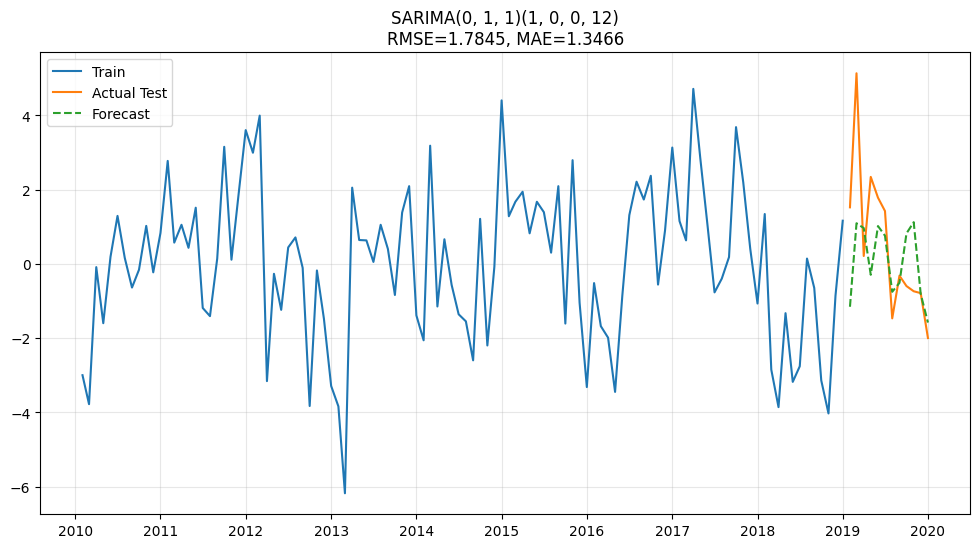

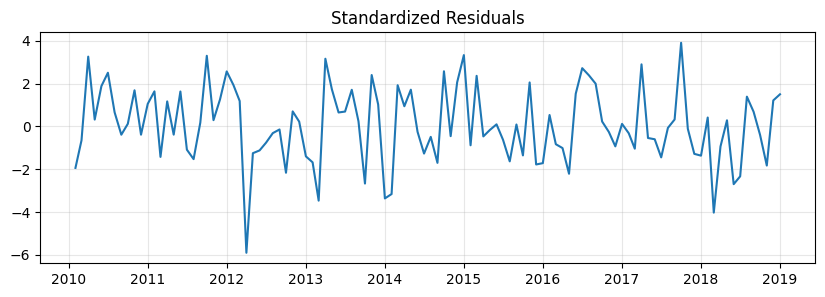

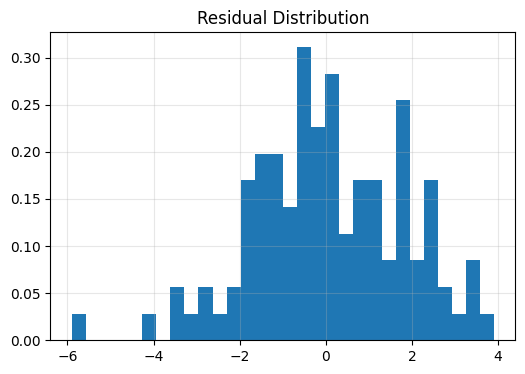

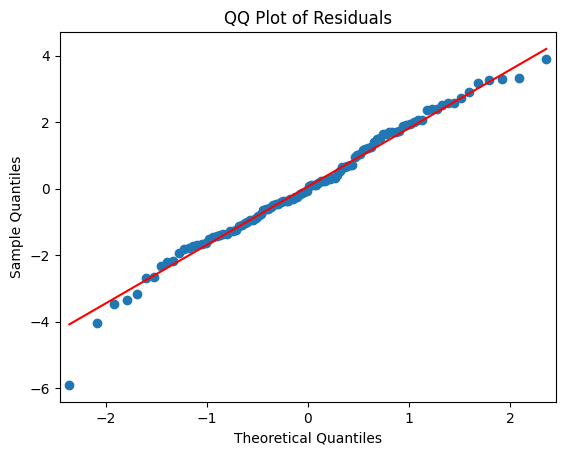

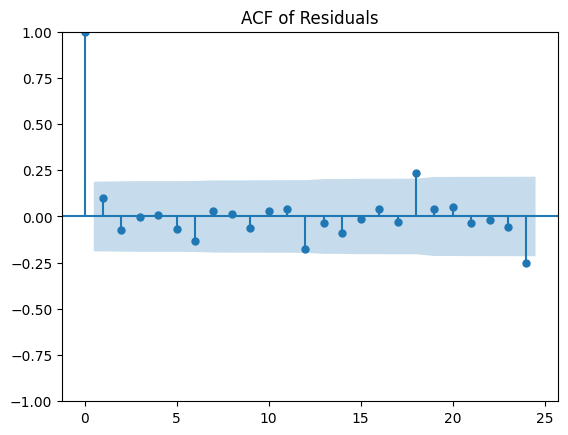

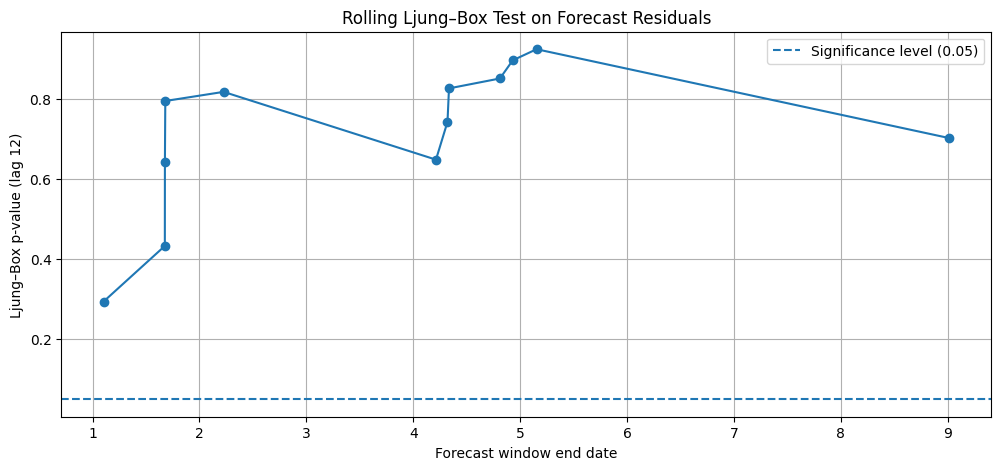

In [17]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=(p,d,q),
    seasonal_order=(P,D,Q,12),
    rmse=rmse,
    mae=mae,
)

In [18]:
from utils import sarima_candidates_from_acf

cand_res = sarima_candidates_from_acf(data[target], m=12, max_p=3, max_q=2, max_P=3, max_Q=3, max_lag=50)

candidates = cand_res["candidates"]
for i, (p, d, q, P, D, Q, s) in enumerate(candidates, 1):
    print(f"{i:02d}. SARIMA({p},{d},{q})({P},{D},{Q},{s})")

n: 289
NaNs: 0
var: 3.8649507046132094
01. SARIMA(0,0,0)(0,0,0,12)
02. SARIMA(0,0,0)(0,0,1,12)
03. SARIMA(0,0,0)(1,0,0,12)
04. SARIMA(0,0,0)(1,0,1,12)
05. SARIMA(0,0,0)(2,0,0,12)
06. SARIMA(0,0,0)(2,0,1,12)
07. SARIMA(0,0,0)(3,0,0,12)
08. SARIMA(0,0,0)(3,0,1,12)
09. SARIMA(0,0,1)(0,0,0,12)
10. SARIMA(0,0,1)(0,0,1,12)
11. SARIMA(0,0,1)(1,0,0,12)
12. SARIMA(0,0,1)(1,0,1,12)
13. SARIMA(0,0,1)(2,0,0,12)
14. SARIMA(0,0,1)(2,0,1,12)
15. SARIMA(0,0,1)(3,0,0,12)
16. SARIMA(0,0,1)(3,0,1,12)
17. SARIMA(0,0,2)(0,0,0,12)
18. SARIMA(0,0,2)(0,0,1,12)
19. SARIMA(0,0,2)(1,0,0,12)
20. SARIMA(0,0,2)(1,0,1,12)
21. SARIMA(0,0,2)(2,0,0,12)
22. SARIMA(0,0,2)(2,0,1,12)
23. SARIMA(0,0,2)(3,0,0,12)
24. SARIMA(0,0,2)(3,0,1,12)
25. SARIMA(1,0,0)(0,0,0,12)
26. SARIMA(1,0,0)(0,0,1,12)
27. SARIMA(1,0,0)(1,0,0,12)
28. SARIMA(1,0,0)(1,0,1,12)
29. SARIMA(1,0,0)(2,0,0,12)
30. SARIMA(1,0,0)(2,0,1,12)
31. SARIMA(1,0,0)(3,0,0,12)
32. SARIMA(1,0,0)(3,0,1,12)
33. SARIMA(1,0,1)(0,0,0,12)
34. SARIMA(1,0,1)(0,0,1,12)
35. SARIM

In [19]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target=target,
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=None,    # or list of exogenous column names
    metric="rmse",
    verbose=True,
)

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=1.9817, MAE=1.5267
Tried SARIMA(0,0,0)(0,0,1,12) -> RMSE=1.4043, MAE=0.9801
Tried SARIMA(0,0,0)(1,0,0,12) -> RMSE=1.8914, MAE=1.5974
Tried SARIMA(0,0,0)(1,0,1,12) -> RMSE=1.4171, MAE=0.9980
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=1.9111, MAE=1.6394
Tried SARIMA(0,0,0)(2,0,1,12) -> RMSE=1.4560, MAE=1.0343
Tried SARIMA(0,0,0)(3,0,0,12) -> RMSE=1.7438, MAE=1.4461
Tried SARIMA(0,0,0)(3,0,1,12) -> RMSE=1.4613, MAE=1.0262
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=1.9616, MAE=1.4972
Tried SARIMA(0,0,1)(0,0,1,12) -> RMSE=1.3203, MAE=0.9317
Tried SARIMA(0,0,1)(1,0,0,12) -> RMSE=1.8736, MAE=1.5820
Tried SARIMA(0,0,1)(1,0,1,12) -> RMSE=1.3172, MAE=0.9288
Tried SARIMA(0,0,1)(2,0,0,12) -> RMSE=1.8589, MAE=1.6117
Tried SARIMA(0,0,1)(2,0,1,12) -> RMSE=1.3070, MAE=0.9122
Tried SARIMA(0,0,1)(3,0,0,12) -> RMSE=1.7056, MAE=1.4399
Tried SARIMA(0,0,1)(3,0,1,12) -> RMSE=1.3532, MAE=0.9606
Tried SARIMA(0,0,2)(0,0,0,12) -> RMSE=1.9255, MAE=1.4754
Tried SARIMA(0,0,2)(0,0,1,12) -

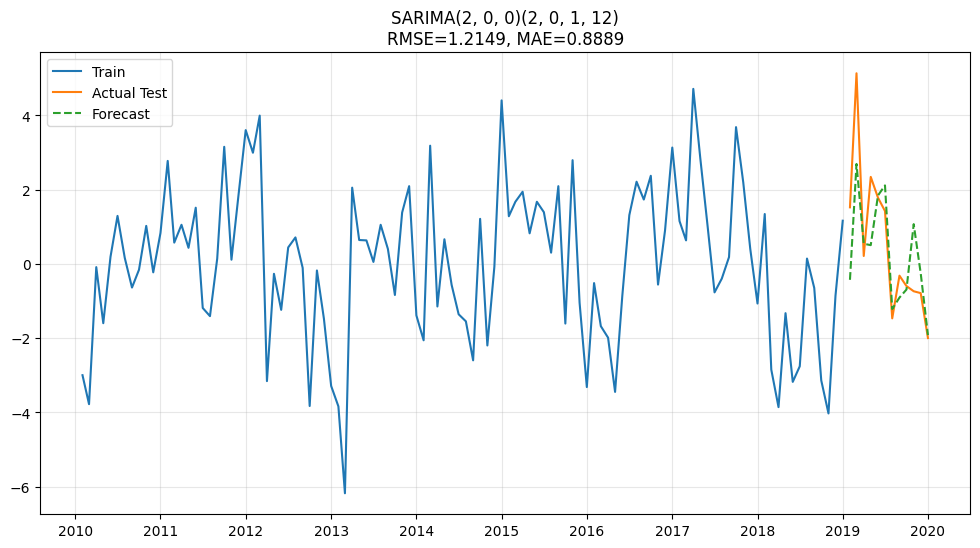

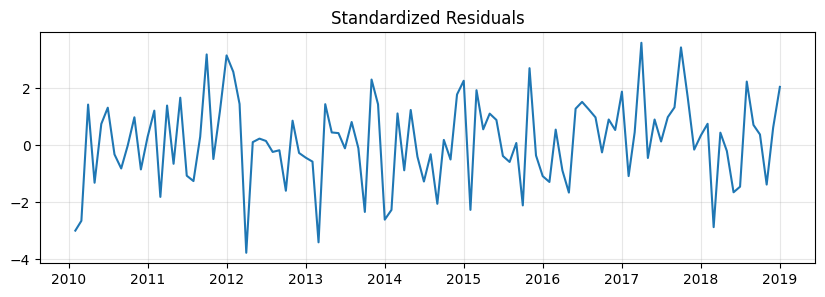

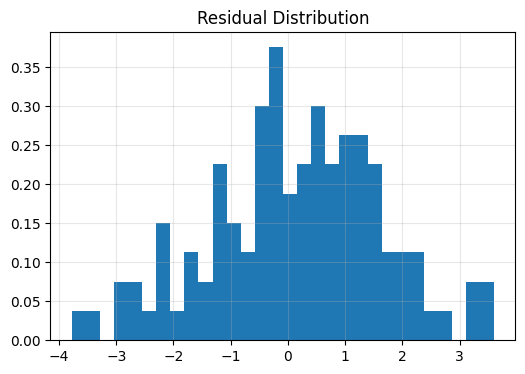

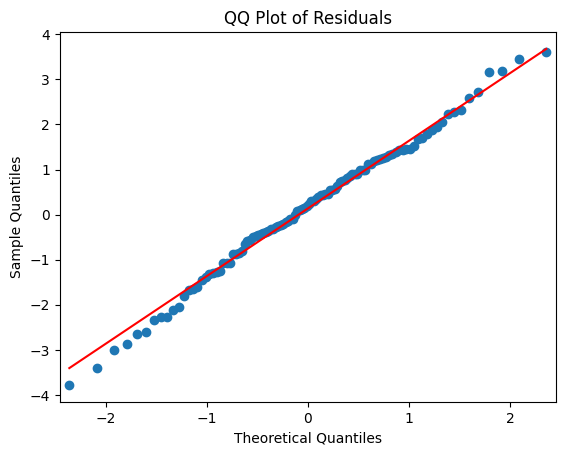

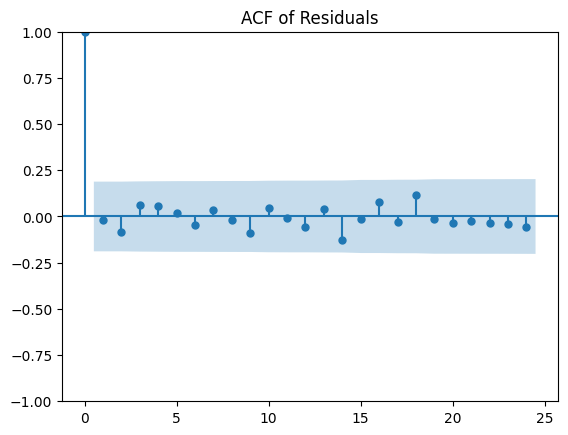

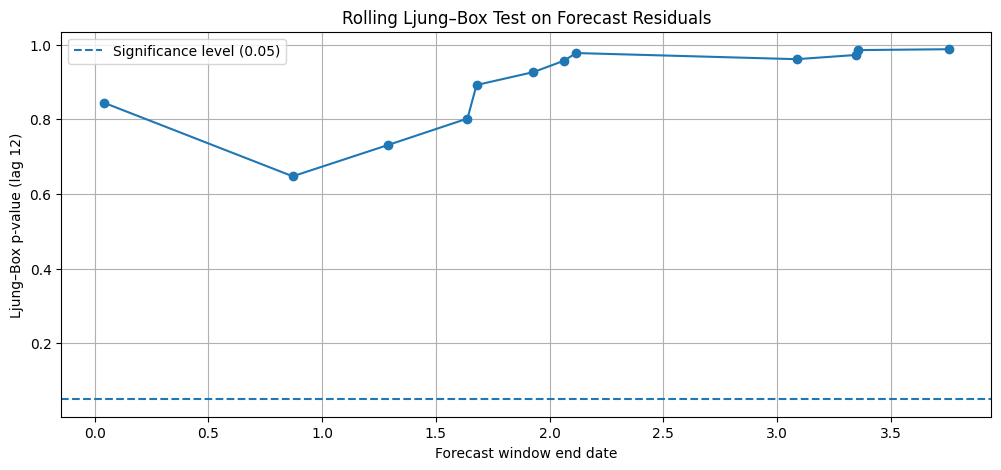

In [20]:
plot_sarimax_results(
    train=best_info["train"],
    test=best_info["test"],
    forecast=best_info["forecast"],
    results=best_info["results"],
    order=best_info["order"],
    seasonal_order=best_info["seasonal_order"],
    rmse=best_info["rmse"],
    mae=best_info["mae"],
)

In [21]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target=target,
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=None,    
    metric="rmse",
    verbose=True,
)

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=1.9817, MAE=1.5267
Tried SARIMA(0,0,0)(0,0,1,12) -> RMSE=1.4043, MAE=0.9801
Tried SARIMA(0,0,0)(1,0,0,12) -> RMSE=1.8914, MAE=1.5974
Tried SARIMA(0,0,0)(1,0,1,12) -> RMSE=1.4171, MAE=0.9980
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=1.9111, MAE=1.6394
Tried SARIMA(0,0,0)(2,0,1,12) -> RMSE=1.4560, MAE=1.0343
Tried SARIMA(0,0,0)(3,0,0,12) -> RMSE=1.7438, MAE=1.4461
Tried SARIMA(0,0,0)(3,0,1,12) -> RMSE=1.4613, MAE=1.0262
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=1.9616, MAE=1.4972
Tried SARIMA(0,0,1)(0,0,1,12) -> RMSE=1.3203, MAE=0.9317
Tried SARIMA(0,0,1)(1,0,0,12) -> RMSE=1.8736, MAE=1.5820
Tried SARIMA(0,0,1)(1,0,1,12) -> RMSE=1.3172, MAE=0.9288
Tried SARIMA(0,0,1)(2,0,0,12) -> RMSE=1.8589, MAE=1.6117
Tried SARIMA(0,0,1)(2,0,1,12) -> RMSE=1.3070, MAE=0.9122
Tried SARIMA(0,0,1)(3,0,0,12) -> RMSE=1.7056, MAE=1.4399
Tried SARIMA(0,0,1)(3,0,1,12) -> RMSE=1.3532, MAE=0.9606
Tried SARIMA(0,0,2)(0,0,0,12) -> RMSE=1.9255, MAE=1.4754
Tried SARIMA(0,0,2)(0,0,1,12) -

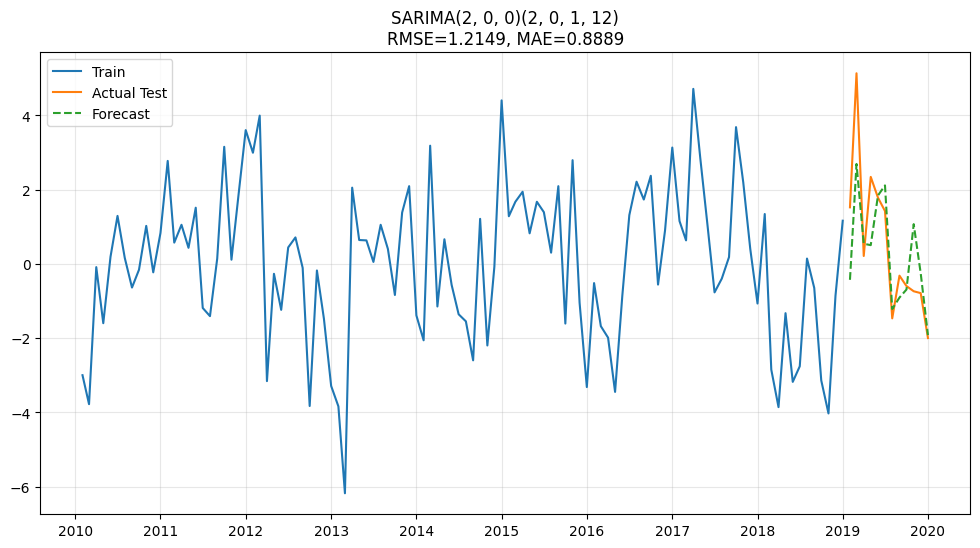

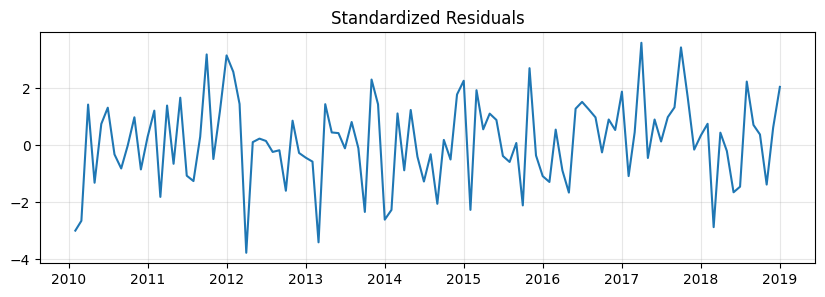

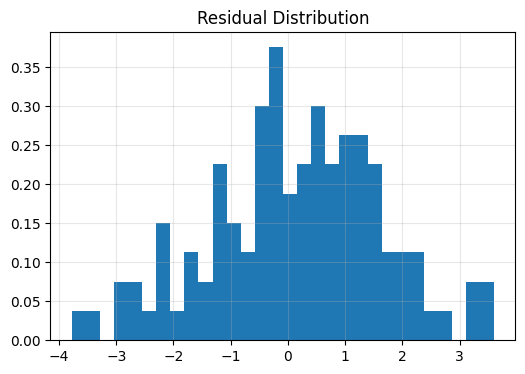

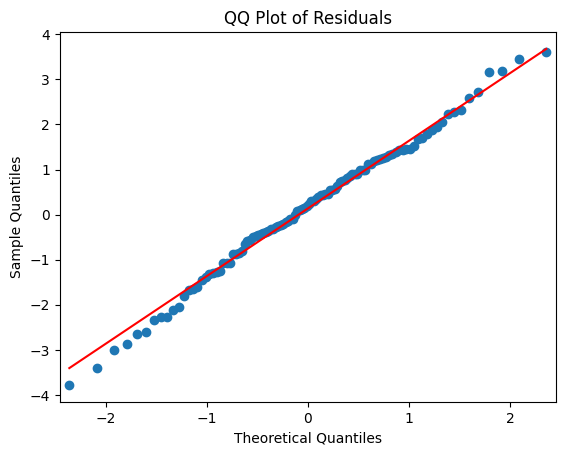

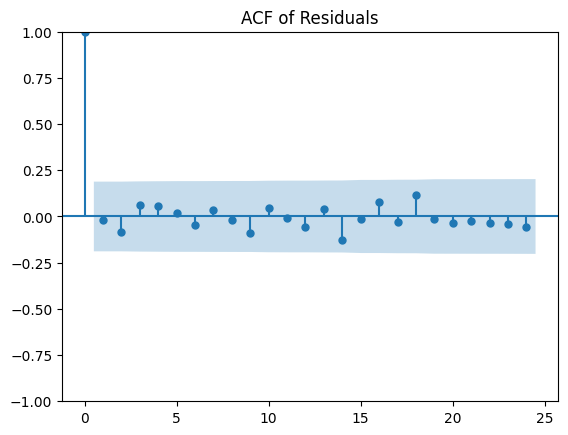

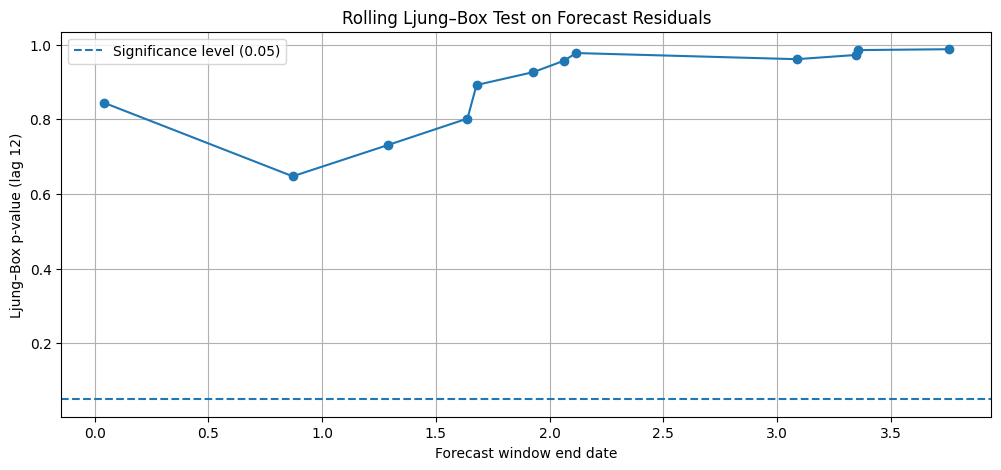

In [22]:
plot_sarimax_results(
    train=train,
    test=best_info["test"],
    forecast=best_info["forecast"],
    results=best_info["results"],
    order=best_info["order"],
    seasonal_order=best_info["seasonal_order"],
    rmse=best_info["rmse"],
    mae=best_info["mae"],
)

In [23]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target=target,
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=exog,    # or list of exogenous column names
    metric="rmse",
    verbose=True,
)

Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=1.5989, MAE=1.2465
Tried SARIMA(0,0,0)(0,0,1,12) -> RMSE=1.4586, MAE=1.2514
Tried SARIMA(0,0,0)(1,0,0,12) -> RMSE=1.7159, MAE=1.5003
Tried SARIMA(0,0,0)(1,0,1,12) -> RMSE=1.5122, MAE=1.3041
Tried SARIMA(0,0,0)(2,0,0,12) -> RMSE=1.8657, MAE=1.7279
Tried SARIMA(0,0,0)(2,0,1,12) -> RMSE=1.5325, MAE=1.2279
Tried SARIMA(0,0,0)(3,0,0,12) -> RMSE=1.7781, MAE=1.6224
Tried SARIMA(0,0,0)(3,0,1,12) -> RMSE=1.8386, MAE=1.6878
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=1.7701, MAE=1.3442
Tried SARIMA(0,0,1)(0,0,1,12) -> RMSE=1.4208, MAE=1.2282
Tried SARIMA(0,0,1)(1,0,0,12) -> RMSE=1.7905, MAE=1.5649
Tried SARIMA(0,0,1)(1,0,1,12) -> RMSE=1.4690, MAE=1.2881
Tried SARIMA(0,0,1)(2,0,0,12) -> RMSE=1.8809, MAE=1.7401
Tried SARIMA(0,0,1)(2,0,1,12) -> RMSE=1.4033, MAE=1.1645
Tried SARIMA(0,0,1)(3,0,0,12) -> RMSE=1.7923, MAE=1.6389
Tried SARIMA(0,0,1)(3,0,1,12) -> RMSE=1.8495, MAE=1.7018
Tried SARIMA(0,0,2)(0,0,0,12) -> RMSE=1.7570, MAE=1.3333
Tried SARIMA(0,0,2)(0,0,1,12) -

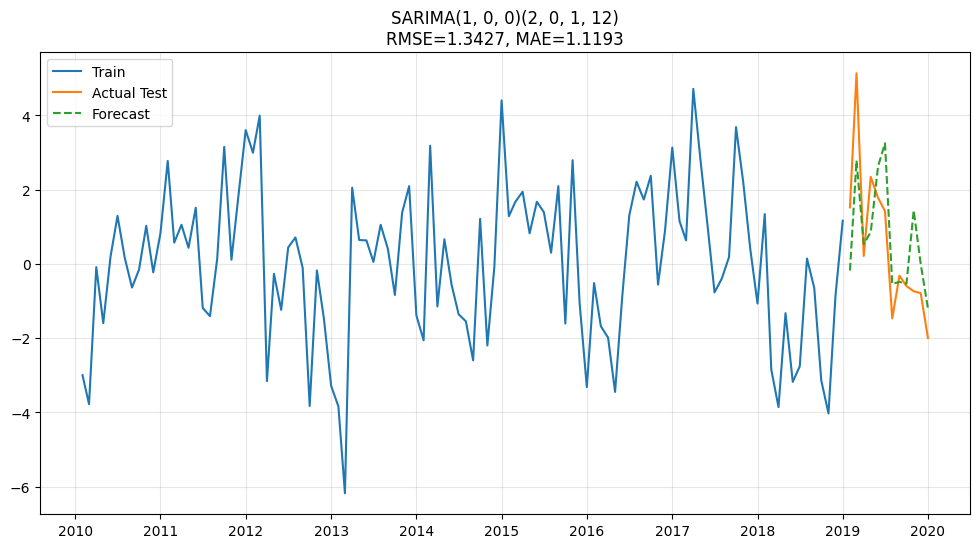

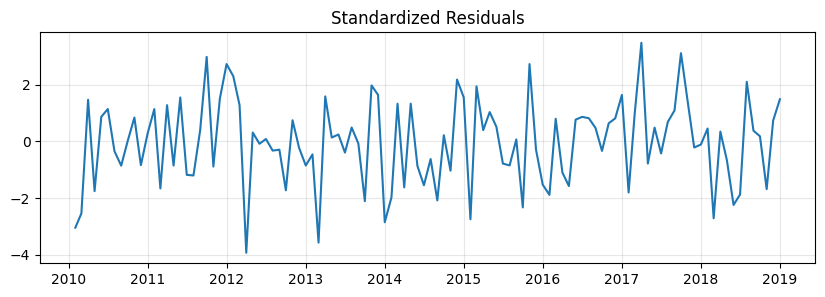

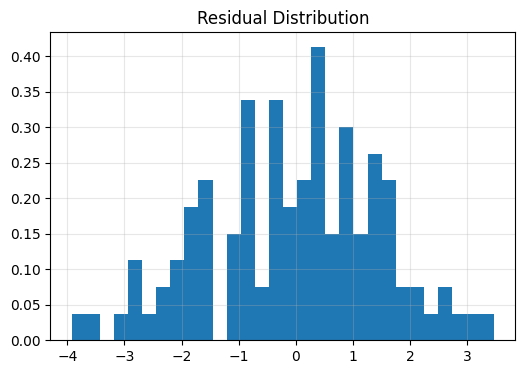

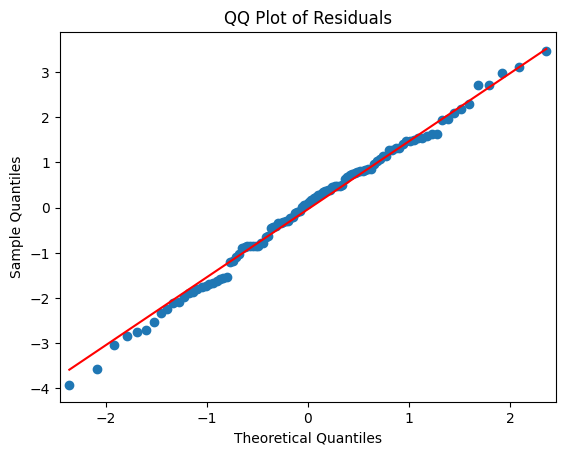

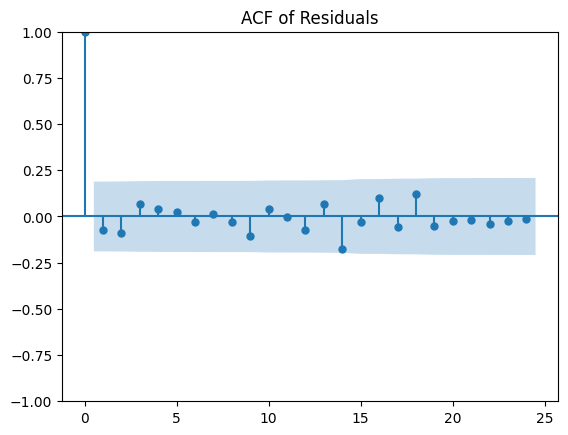

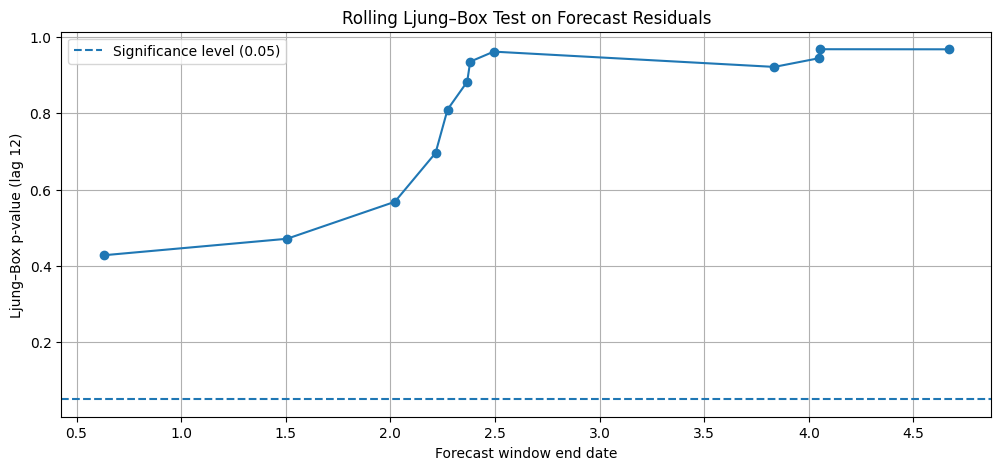

In [24]:
plot_sarimax_results(
    train=best_info["train"],
    test=best_info["test"],
    forecast=best_info["forecast"],
    results=best_info["results"],
    order=best_info["order"],
    seasonal_order=best_info["seasonal_order"],
    rmse=best_info["rmse"],
    mae=best_info["mae"],
)

## Using AutoSarima with the current train/test split

In [25]:
rmse, mae, results, forecast, test, train, order, seasonal_order = auto_sarima_experiment(data, target, forecast_window=12, no_windows=10, m=12)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=469.308, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=427.768, Time=0.07 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.29 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=467.308, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=456.406, Time=0.02 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=416.027, Time=0.16 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.83 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=426.858, Time=0.11 sec
 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=417.956, Time=0.18 sec
 ARIMA(1,0,1)(2,0,0)[12] intercept   : AIC=417.660, Time=0.23 sec
 ARIMA(0,0,1)(2,0,0)[12] intercept   : AIC=417.038, Time=0.15 sec
 ARIMA(2,0,1)(2,0,0)[12] intercept   : AIC=419.155, Time=0.53 sec
 ARIMA(1,0,0)(2,0,0)[12]             : AIC=414.781, Time=0.08 sec
 ARIMA(1,0,0)(1,0,0)[12]             : AIC=42

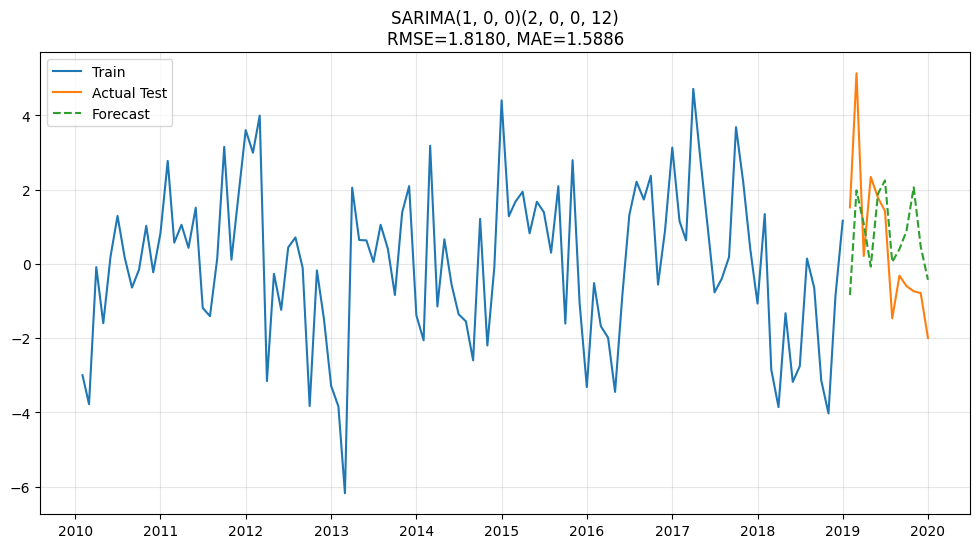

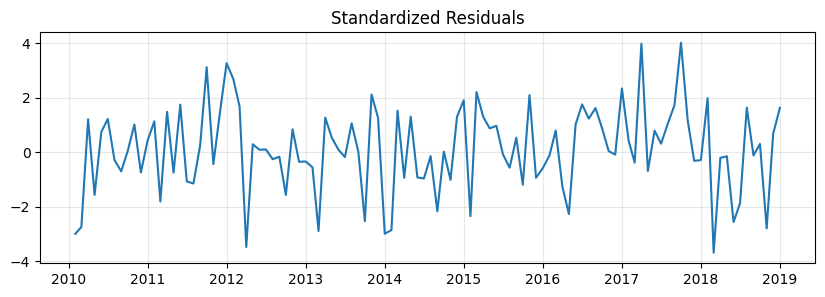

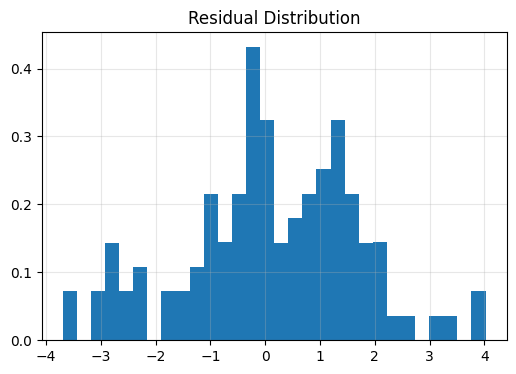

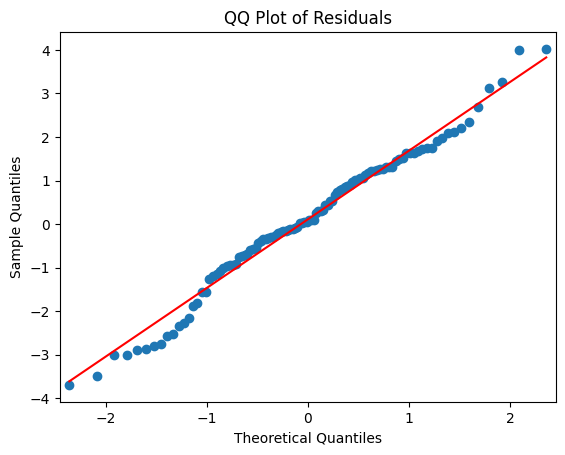

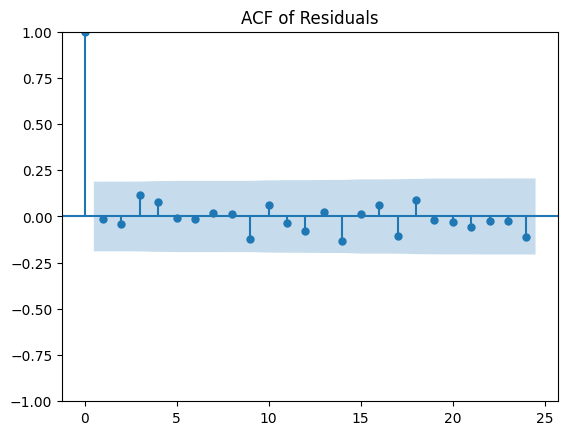

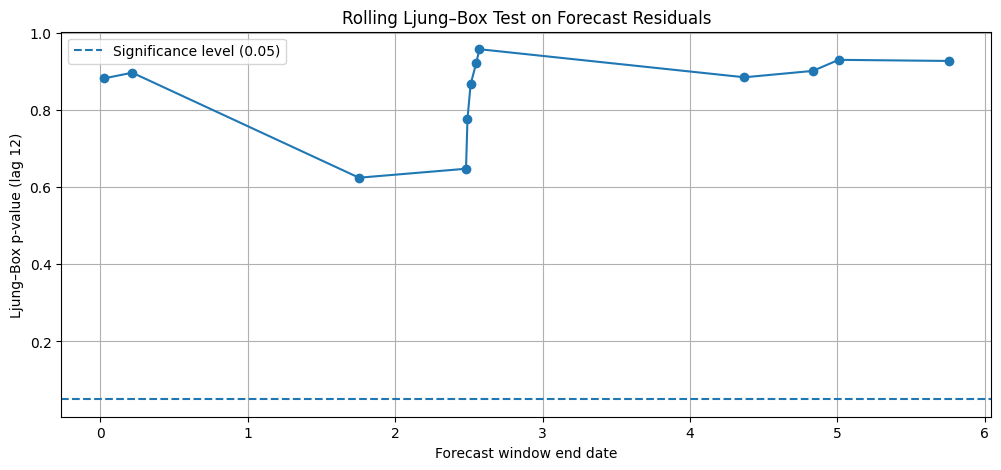

In [26]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=order,
    seasonal_order=seasonal_order,
    rmse=rmse,
    mae=mae,
)

In [27]:
rmse, mae, results, forecast, test, train, order, seasonal_order = auto_sarima_experiment(data, target, forecast_window=12, no_windows=10, m=12, exog=exog)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=469.308, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=427.768, Time=0.06 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=467.308, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=456.406, Time=0.02 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=416.027, Time=0.13 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.69 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=426.858, Time=0.11 sec
 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=417.956, Time=0.16 sec
 ARIMA(1,0,1)(2,0,0)[12] intercept   : AIC=417.660, Time=0.23 sec
 ARIMA(0,0,1)(2,0,0)[12] intercept   : AIC=417.038, Time=0.15 sec
 ARIMA(2,0,1)(2,0,0)[12] intercept   : AIC=419.155, Time=0.57 sec
 ARIMA(1,0,0)(2,0,0)[12]             : AIC=414.781, Time=0.09 sec
 ARIMA(1,0,0)(1,0,0)[12]             : AIC=42

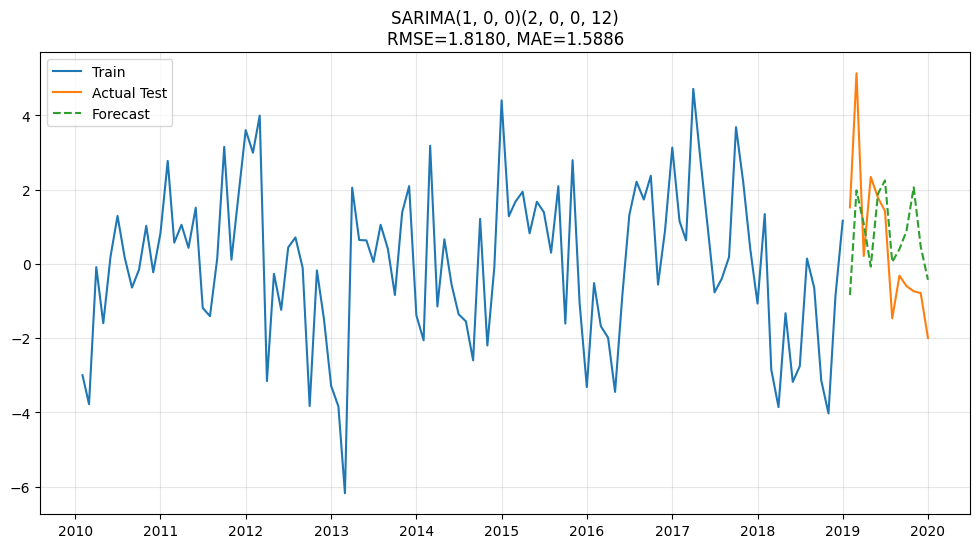

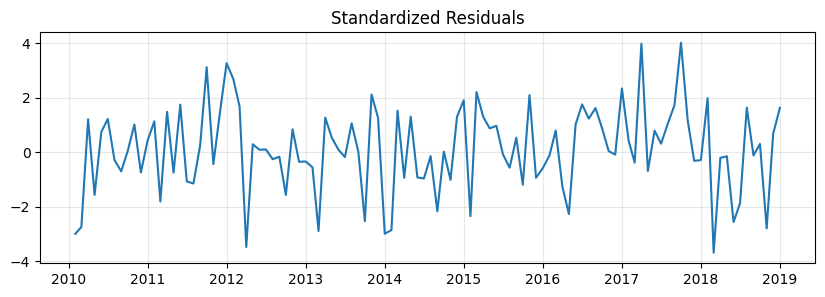

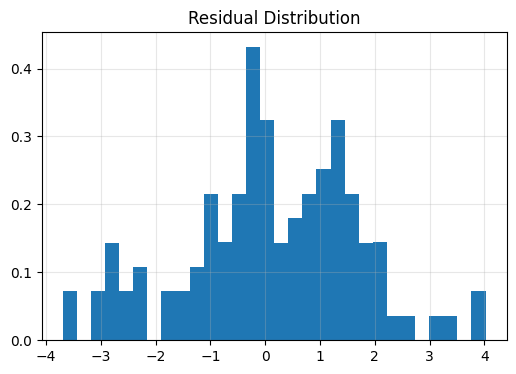

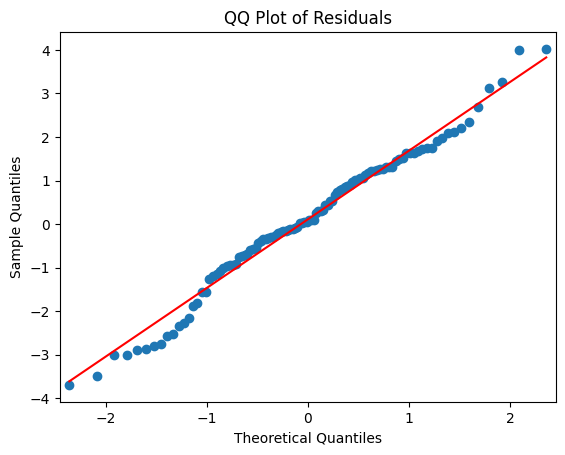

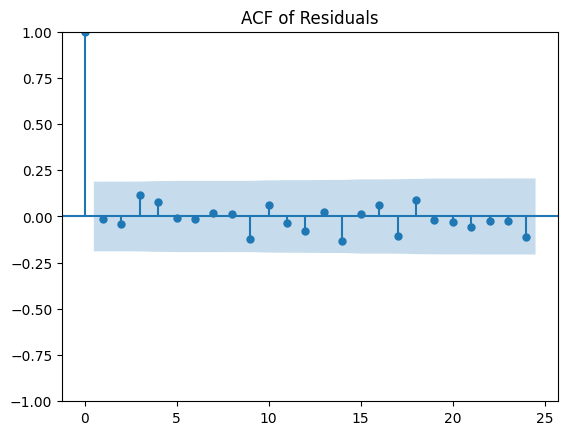

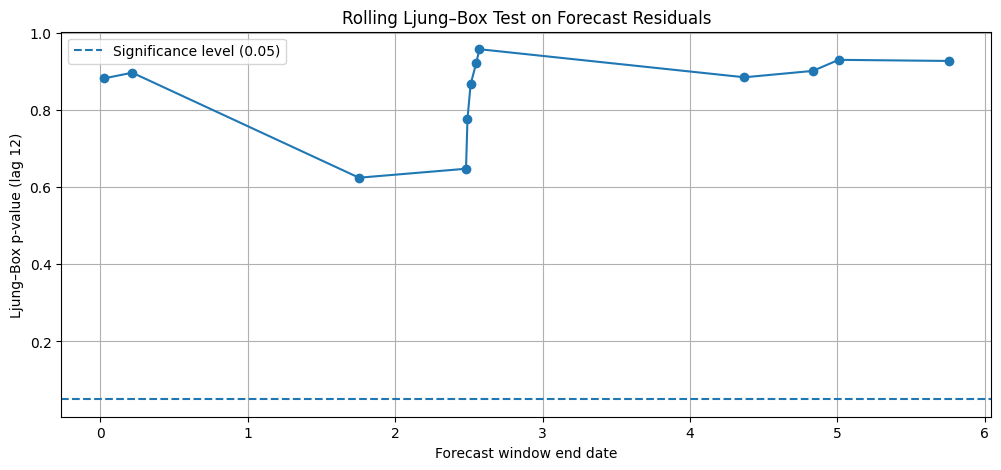

In [28]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=order,
    seasonal_order=seasonal_order,
    rmse=rmse,
    mae=mae,
)

In [29]:
h = 12
years_test = 2
years_train = 8
forecast_window = h * years_test
step = h
train_size = h * years_train
best_info, scores_df  = select_best_sarima_cv(
    data,
    target,
    candidates=candidates,
    forecast_window=forecast_window,
    train_size=train_size,
    step=step,
    exog=None,
)

Running rolling CV with 15 folds...
01. SARIMA(0,0,0)(0,0,0,12) - mean RMSE=1.9296, mean MAE=1.5371
Running rolling CV with 15 folds...
02. SARIMA(0,0,0)(0,0,1,12) - mean RMSE=1.7032, mean MAE=1.3383
Running rolling CV with 15 folds...
03. SARIMA(0,0,0)(1,0,0,12) - mean RMSE=1.8552, mean MAE=1.4352
Running rolling CV with 15 folds...
04. SARIMA(0,0,0)(1,0,1,12) - mean RMSE=1.7343, mean MAE=1.3570
Running rolling CV with 15 folds...
05. SARIMA(0,0,0)(2,0,0,12) - mean RMSE=1.7760, mean MAE=1.4178
Running rolling CV with 15 folds...
06. SARIMA(0,0,0)(2,0,1,12) - mean RMSE=1.7560, mean MAE=1.4068
Running rolling CV with 15 folds...
07. SARIMA(0,0,0)(3,0,0,12) - mean RMSE=1.7711, mean MAE=1.4121
Running rolling CV with 15 folds...
08. SARIMA(0,0,0)(3,0,1,12) - mean RMSE=1.7959, mean MAE=1.4427
Running rolling CV with 15 folds...
09. SARIMA(0,0,1)(0,0,0,12) - mean RMSE=1.9242, mean MAE=1.5341
Running rolling CV with 15 folds...
10. SARIMA(0,0,1)(0,0,1,12) - mean RMSE=1.6950, mean MAE=1.3304


In [30]:
p, d, q = best_info["order"][0] , best_info["order"][1], best_info["order"][2]
P, D, Q, s = best_info["seasonal_order"][0], best_info["seasonal_order"][1], best_info["seasonal_order"][2], best_info["seasonal_order"][3]
rmse, mae, results_train, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s)

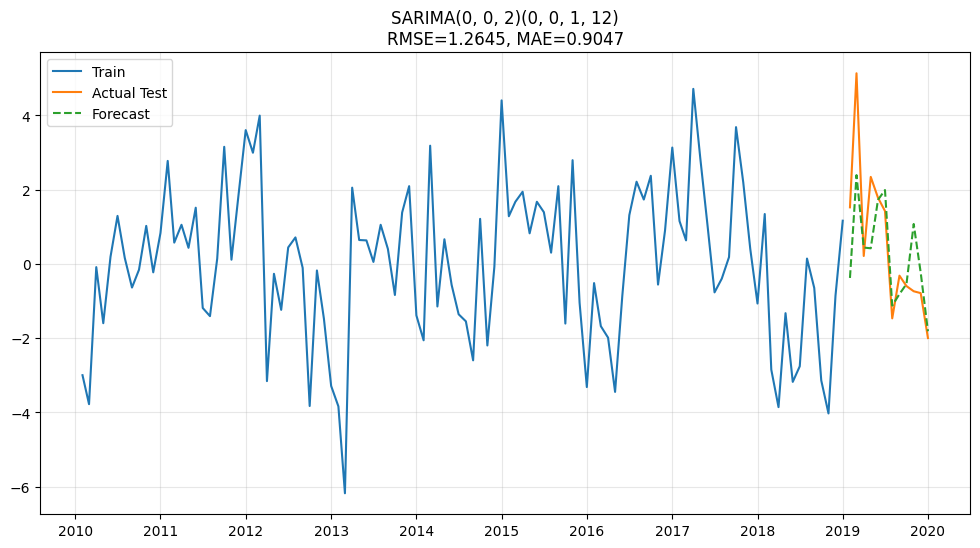

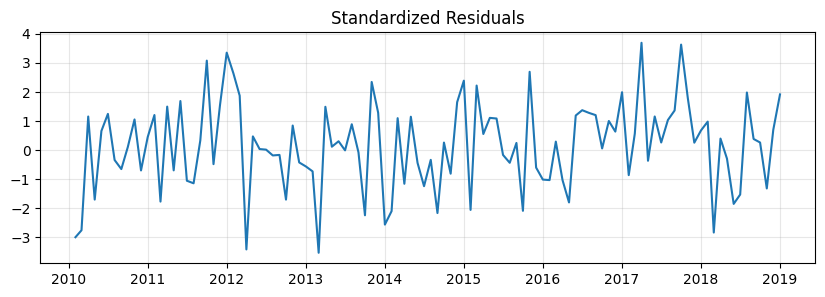

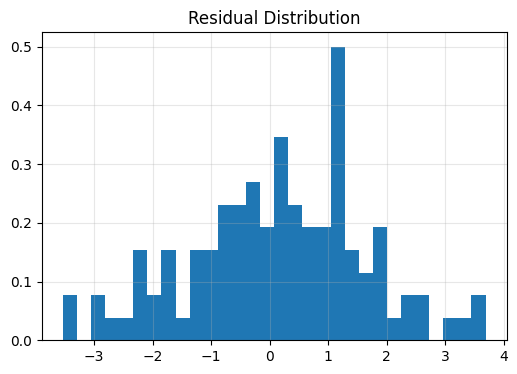

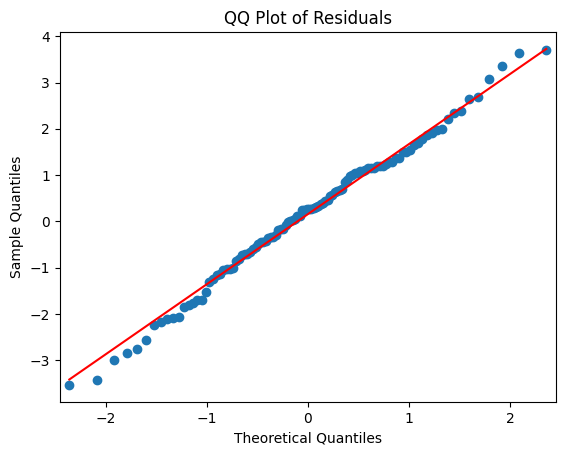

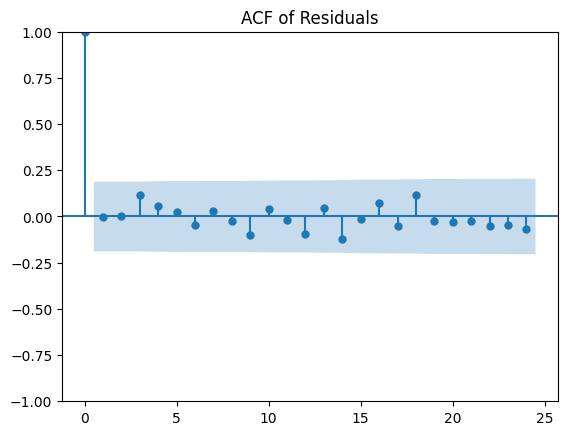

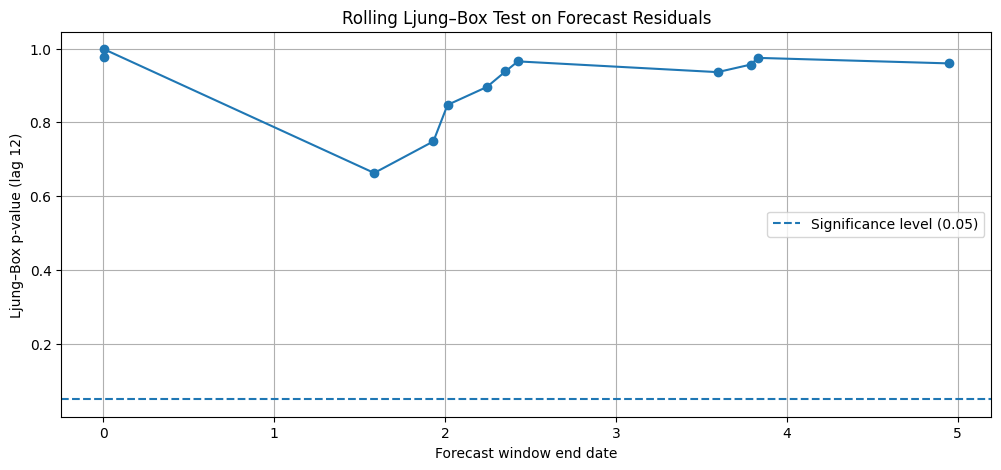

In [31]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results_train,     # ✅ use results_train
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    rmse=rmse,
    mae=mae,
)

In [32]:
best_info, scores_df  = select_best_sarima_cv(
    data,
    target,
    candidates=candidates,
    forecast_window=forecast_window,
    train_size=train_size,
    step=step,
    exog=exog,
)

Running rolling CV with 15 folds...
01. SARIMA(0,0,0)(0,0,0,12) - mean RMSE=1.9203, mean MAE=1.5256
Running rolling CV with 15 folds...
02. SARIMA(0,0,0)(0,0,1,12) - mean RMSE=1.7660, mean MAE=1.3881
Running rolling CV with 15 folds...
03. SARIMA(0,0,0)(1,0,0,12) - mean RMSE=1.8650, mean MAE=1.4531
Running rolling CV with 15 folds...
04. SARIMA(0,0,0)(1,0,1,12) - mean RMSE=1.7966, mean MAE=1.4085
Running rolling CV with 15 folds...
05. SARIMA(0,0,0)(2,0,0,12) - mean RMSE=1.8129, mean MAE=1.4414
Running rolling CV with 15 folds...
06. SARIMA(0,0,0)(2,0,1,12) - mean RMSE=1.8196, mean MAE=1.4485
Running rolling CV with 15 folds...
07. SARIMA(0,0,0)(3,0,0,12) - mean RMSE=1.8467, mean MAE=1.4691
Running rolling CV with 15 folds...
08. SARIMA(0,0,0)(3,0,1,12) - mean RMSE=1.8574, mean MAE=1.4747
Running rolling CV with 15 folds...
09. SARIMA(0,0,1)(0,0,0,12) - mean RMSE=1.9358, mean MAE=1.5441
Running rolling CV with 15 folds...
10. SARIMA(0,0,1)(0,0,1,12) - mean RMSE=1.7723, mean MAE=1.3924


In [33]:
p, d, q = best_info["order"][0] , best_info["order"][1], best_info["order"][2]
P, D, Q, s = best_info["seasonal_order"][0], best_info["seasonal_order"][1], best_info["seasonal_order"][2], best_info["seasonal_order"][3]
rmse, mae, results_train, forecast, test, train = sarimax_experiment(data, target, p, d, q, P, D, Q, s)

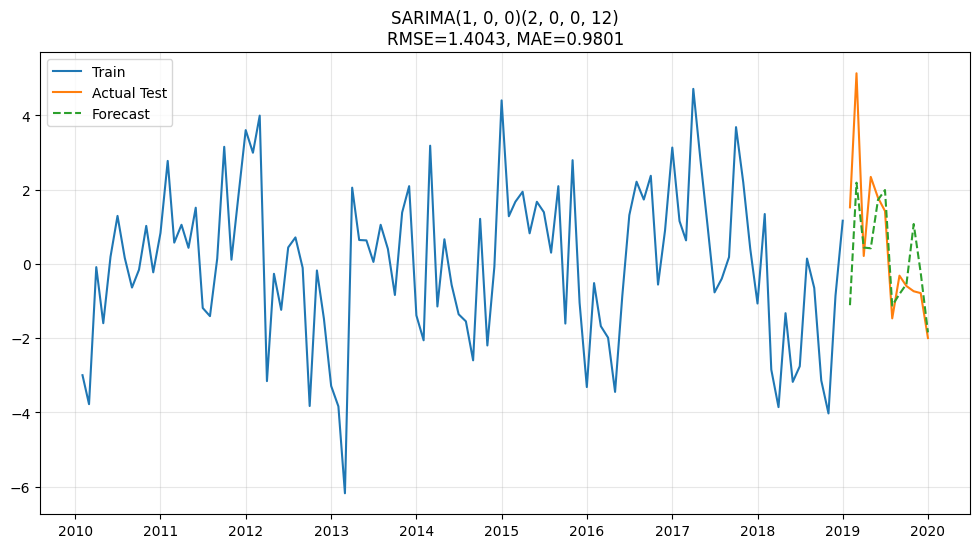

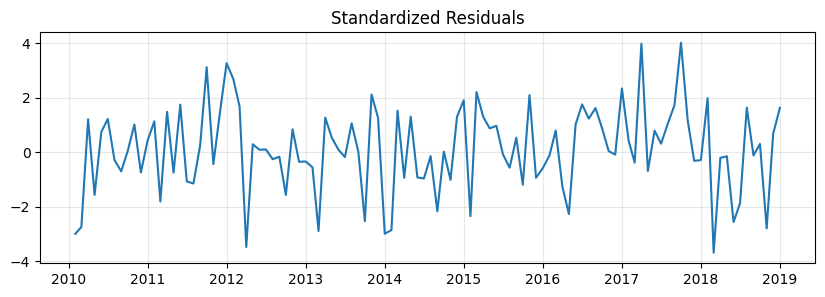

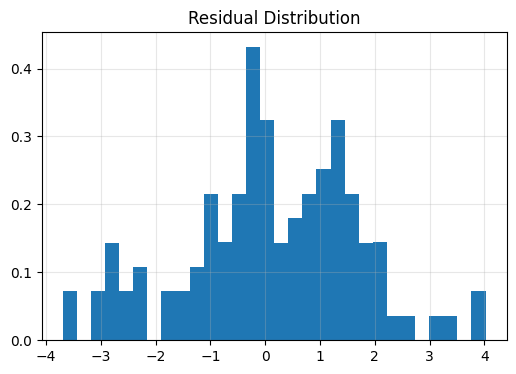

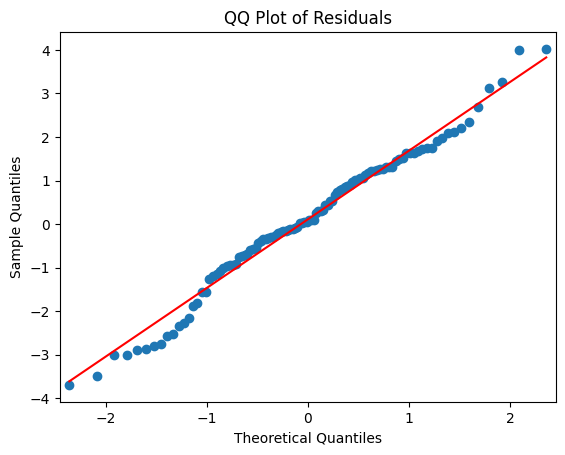

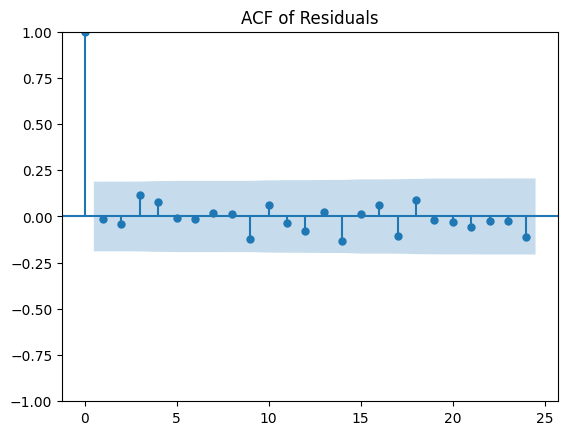

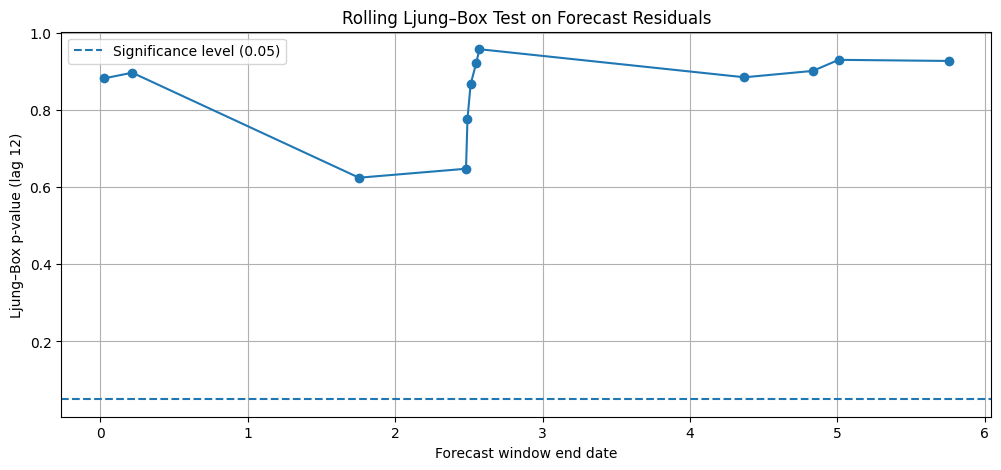

In [34]:
plot_sarimax_results(
    train=train,
    test=test,
    forecast=forecast,
    results=results,
    order=order,
    seasonal_order=seasonal_order,
    rmse=rmse,
    mae=mae,
)

# LSTMs

In [35]:
res = lstm_grid_search_cv(data, 'tdiff', train_years=8, forecast_months=24, test_start_year=1996, epochs=60, verbose=0, param_grid={
    'exog': [['lagged_tmed', 'lagged_tmin', 'lagged_prec', 'lagged_tmax'], ['lagged_tmin', 'lagged_prec', 'lagged_tmax'], ['lagged_tmed', 'lagged_prec'], ['lagged_tmin', 'lagged_prec', 'lagged_tmax']],
    'lr': [0.001],
    'hidden_size': [50, 25, 100],
    'num_layers': [1, 2],
    'dropout': [0.1, 0.2, 0.3]
    
})

In [36]:
print_grid_search_results(res['results'], res['best_overall_score'], res['best_overall_results'], res['best_overall_params'],res['best_avg_score'], res['best_avg_results'], res['best_avg_params'],res['best_last_fold_score'], res['best_last_fold_results'], res['best_last_fold_params'])


GRID SEARCH COMPLETE

BEST MODEL BY OVERALL RMSE (concatenated predictions)
Overall RMSE: 1.4737
Overall MAE: 1.1410
Average RMSE: 1.4491
Average MAE: 1.1410

Parameters:
  exog: ['lagged_tmed', 'lagged_tmin', 'lagged_prec', 'lagged_tmax']
  lr: 0.001
  hidden_size: 100
  num_layers: 1
  dropout: 0.3

BEST MODEL BY AVERAGE RMSE (across folds)
Average RMSE: 1.4491
Average MAE: 1.1410
Overall RMSE: 1.4737
Overall MAE: 1.1410

Parameters:
  exog: ['lagged_tmed', 'lagged_tmin', 'lagged_prec', 'lagged_tmax']
  lr: 0.001
  hidden_size: 100
  num_layers: 1
  dropout: 0.3

BEST MODEL BY LAST FOLD RMSE (most recent period)
Last Fold RMSE: 1.6143
Last Fold MAE: 1.2977
Test Period: 2018-01 to 2019-12
Overall RMSE: 1.6544
Average RMSE: 1.6111

Parameters:
  exog: ['lagged_tmed', 'lagged_tmin', 'lagged_prec', 'lagged_tmax']
  lr: 0.001
  hidden_size: 25
  num_layers: 1
  dropout: 0.3

TOP 10 MODELS BY AVG RMSE
 combination                                                         exog    lr  hidden_

Data range: 1996 to 2020
Training window: 8 years (96 months)
Forecast horizon: 24 months
Sequence length: 24 months
Testing period: 1996 onwards
Number of CV splits: 8
Exogenous variables: lagged_tmin, lagged_prec, lagged_tmax, lagged_tdiff

Split 1/8

  Train: 1996-01 to 2003-12
  Test:  2004-01 to 2005-12
  RMSE: 1.9159, MAE: 1.6525

Split 2/8

  Train: 1998-01 to 2005-12
  Test:  2006-01 to 2007-12
  RMSE: 1.2818, MAE: 1.0760

Split 3/8

  Train: 2000-01 to 2007-12
  Test:  2008-01 to 2009-12
  RMSE: 1.2324, MAE: 0.9224

Split 4/8

  Train: 2002-01 to 2009-12
  Test:  2010-01 to 2011-12
  RMSE: 1.1311, MAE: 0.9019

Split 5/8

  Train: 2004-01 to 2011-12
  Test:  2012-01 to 2013-12
  RMSE: 1.8425, MAE: 1.3550

Split 6/8

  Train: 2006-01 to 2013-12
  Test:  2014-01 to 2015-12
  RMSE: 1.1924, MAE: 1.0683

Split 7/8

  Train: 2008-01 to 2015-12
  Test:  2016-01 to 2017-12
  RMSE: 1.9919, MAE: 1.6810

Split 8/8

  Train: 2010-01 to 2017-12
  Test:  2018-01 to 2019-12
  RMSE: 1.7464, MA

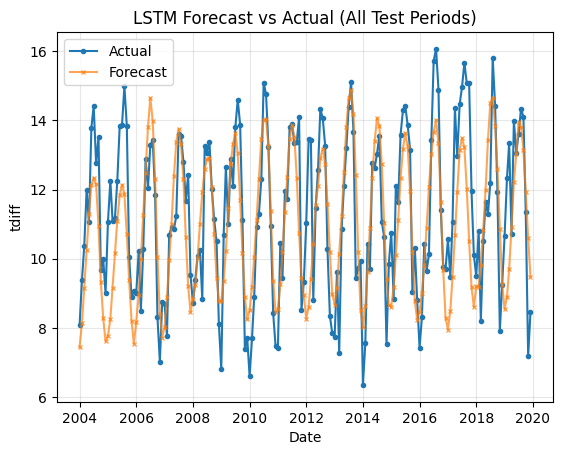

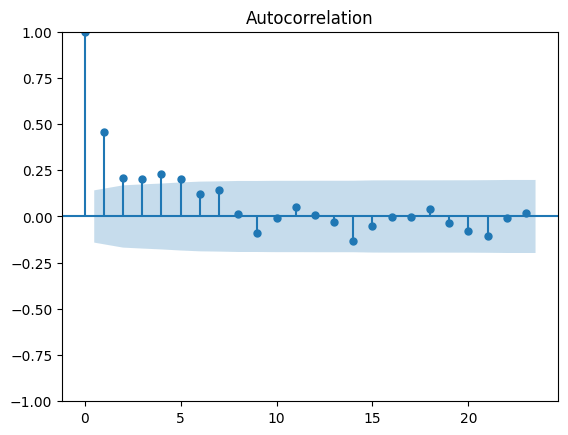

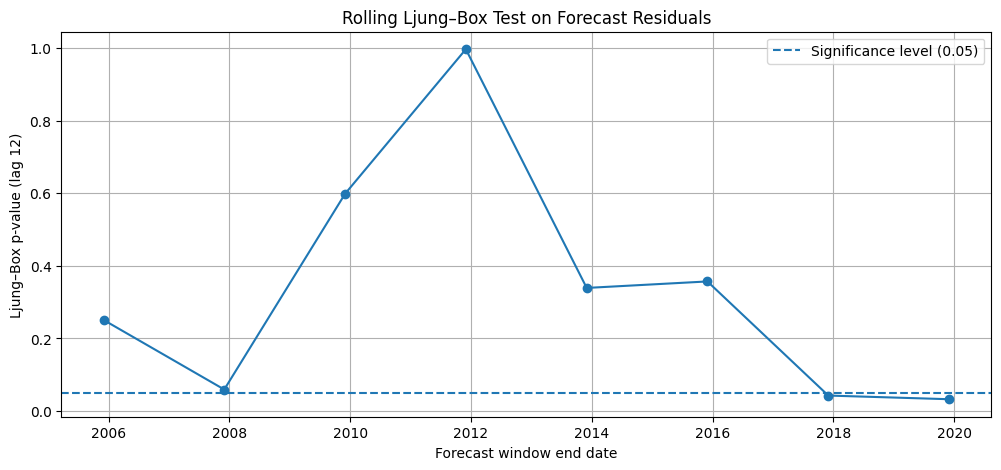

<Figure size 640x480 with 0 Axes>

In [37]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=1996,
    exog=['lagged_tmed_24', 'lagged_tmin_24', 'lagged_prec_24', 'lagged_tmax_24', 'lagged_tdiff_24'],  
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=100,
    num_layers=1,
    dropout=0.2,
    plot=True,
)

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=1996,
    exog=['lagged_tmed_12', 'lagged_tmin_12', 'lagged_prec_12', 'lagged_tmax_12', 'lagged_tdiff_12'], 
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=25,
    num_layers=2,
    dropout=0.2,
    plot=True,
)

Data range: 1996 to 2020
Training window: 8 years (96 months)
Forecast horizon: 24 months
Sequence length: 24 months
Testing period: 1996 onwards
Number of CV splits: 8
Exogenous variables: lagged_tmed, lagged_tmin, lagged_prec, lagged_tmax, lagged_tdiff

Split 1/8

  Train: 1996-01 to 2003-12
  Test:  2004-01 to 2005-12
  RMSE: 1.7997, MAE: 1.5082

Split 2/8

  Train: 1998-01 to 2005-12
  Test:  2006-01 to 2007-12
  RMSE: 1.2149, MAE: 1.0742

Split 3/8

  Train: 2000-01 to 2007-12
  Test:  2008-01 to 2009-12
  RMSE: 1.4789, MAE: 1.1315

Split 4/8

  Train: 2002-01 to 2009-12
  Test:  2010-01 to 2011-12
  RMSE: 1.2357, MAE: 1.0209

Split 5/8

  Train: 2004-01 to 2011-12
  Test:  2012-01 to 2013-12
  RMSE: 1.8294, MAE: 1.3198

Split 6/8

  Train: 2006-01 to 2013-12
  Test:  2014-01 to 2015-12
  RMSE: 1.2810, MAE: 1.1282

Split 7/8

  Train: 2008-01 to 2015-12
  Test:  2016-01 to 2017-12
  RMSE: 2.2477, MAE: 1.8467

Split 8/8

  Train: 2010-01 to 2017-12
  Test:  2018-01 to 2019-12
  RMS

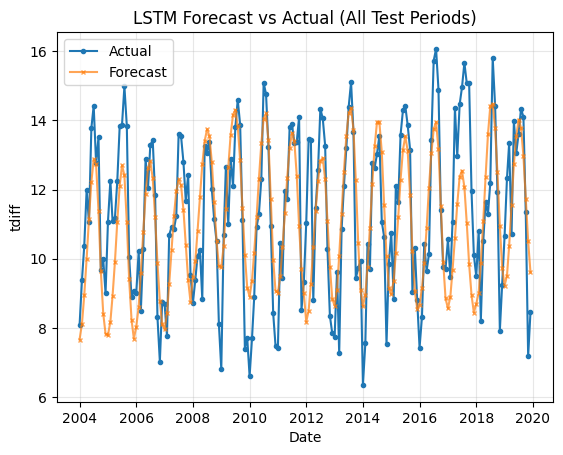

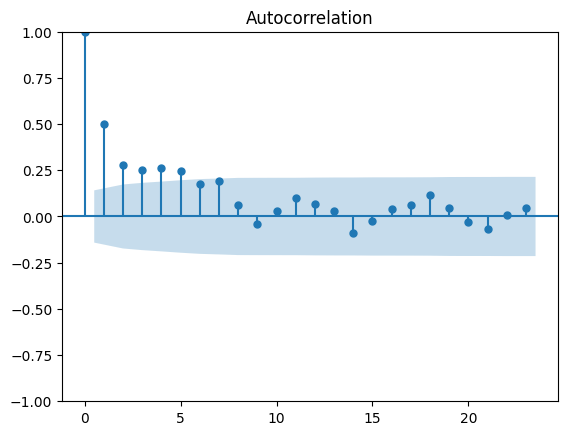

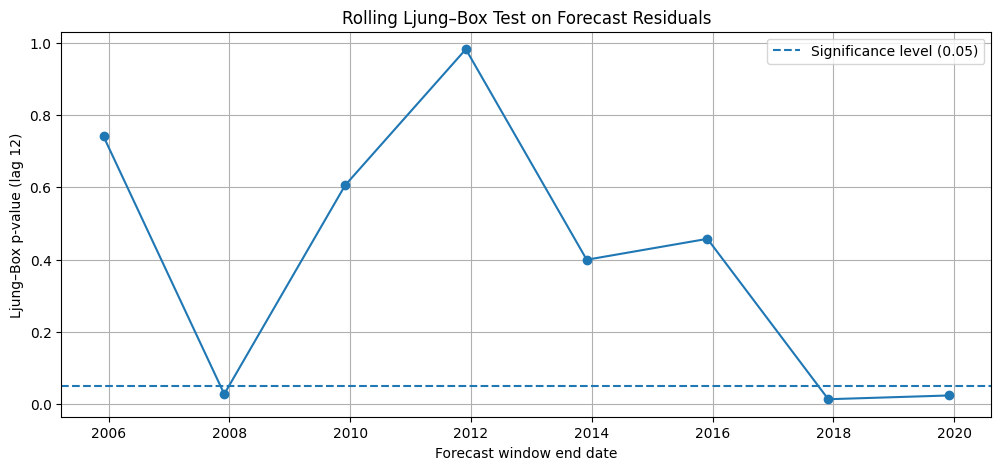

<Figure size 640x480 with 0 Axes>

In [ ]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=1996,
    exog=['lagged_tmed_1', 'lagged_tmin_1', 'lagged_prec_1', 'lagged_tmax_1', 'lagged_tdiff_1', 'lagged_tmed_12', 'lagged_tmin_12', 'lagged_prec_12', 'lagged_tmax_12', 'lagged_tdiff_12' ], 
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=25,
    num_layers=2,
    dropout=0.2,
    plot=True,
)

Data range: 1996 to 2020
Training window: 8 years (96 months)
Forecast horizon: 24 months
Sequence length: 24 months
Testing period: 2010 onwards
Number of CV splits: 1
Exogenous variables: lagged_tmed, lagged_tmin, lagged_prec, lagged_tmax, lagged_tdiff

Split 1/1

  Train: 2010-01 to 2017-12
  Test:  2018-01 to 2019-12
  RMSE: 1.6720, MAE: 1.3595


OVERALL METRICS (concatenated predictions):
RMSE: 1.6720
MAE: 1.3595

AVERAGE METRICS (across splits):
Average RMSE: 1.6720, STD:  0.0000
Average MAE: 1.3595, STD:  0.0000



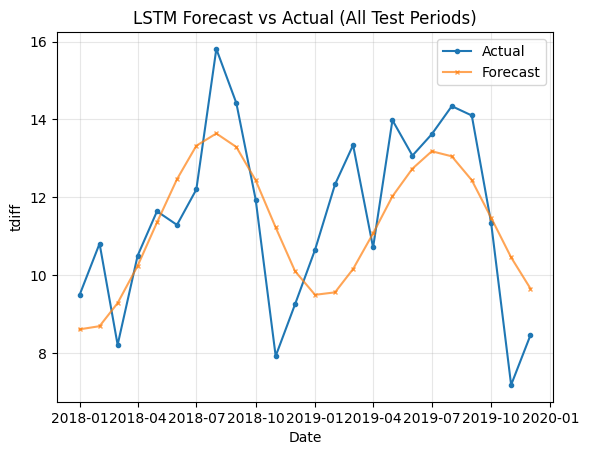

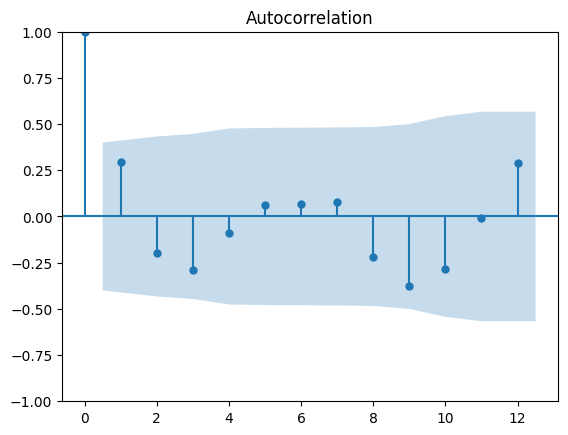

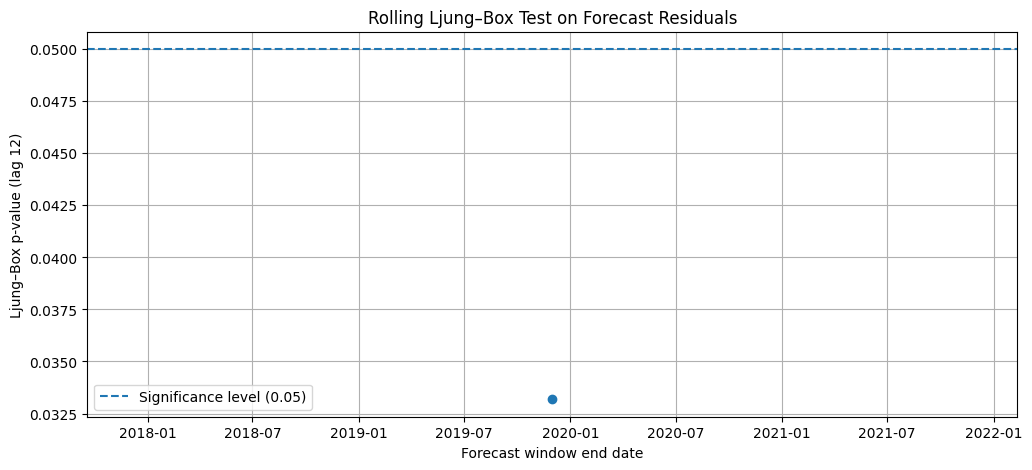

<Figure size 640x480 with 0 Axes>

In [39]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=2010,
    exog=['lagged_tmed', 'lagged_tmin', 'lagged_prec', 'lagged_tmax', 'lagged_tdiff'], 
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=25,
    num_layers=2,
    dropout=0.2,
    plot=True,
)

Data range: 1996 to 2020
Training window: 8 years (96 months)
Forecast horizon: 24 months
Sequence length: 24 months
Testing period: 2010 onwards
Number of CV splits: 1
Exogenous variables: lagged_tmin, lagged_prec, lagged_tmax, lagged_tdiff

Split 1/1

  Train: 2010-01 to 2017-12
  Test:  2018-01 to 2019-12
  RMSE: 1.7136, MAE: 1.3345


OVERALL METRICS (concatenated predictions):
RMSE: 1.7136
MAE: 1.3345

AVERAGE METRICS (across splits):
Average RMSE: 1.7136, STD:  0.0000
Average MAE: 1.3345, STD:  0.0000



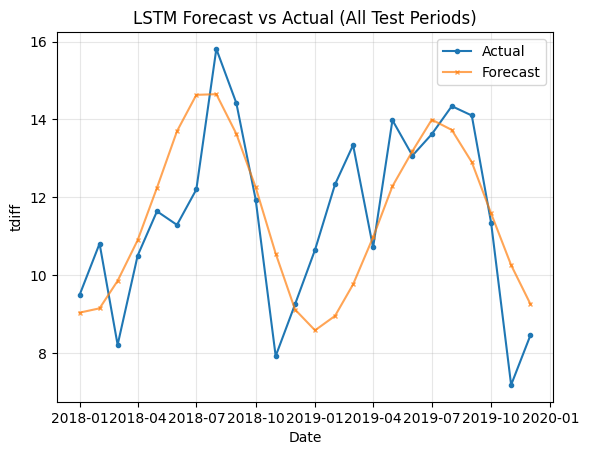

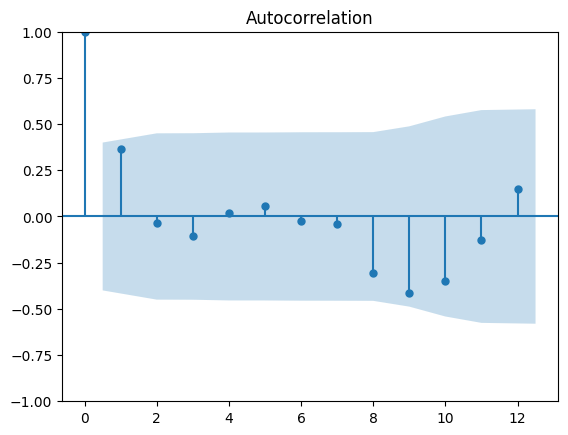

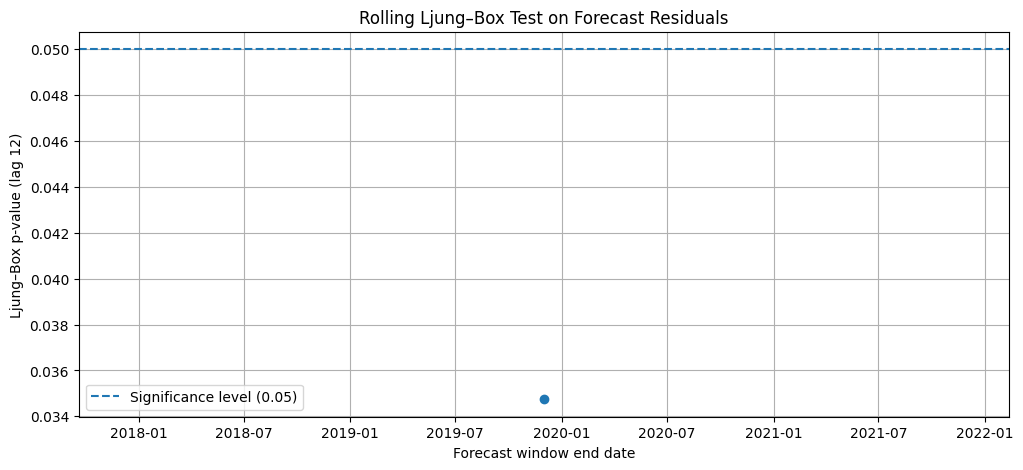

<Figure size 640x480 with 0 Axes>

In [40]:
results = lstm_time_series_cv(
    df=data,
    target='tdiff',
    train_years=8,
    forecast_months=24,
    test_start_year=2010,
    exog=['lagged_tmin_24', 'lagged_prec_24', 'lagged_tmax_24', 'lagged_tdiff_24'],  
    seq_length=24,
    epochs=60,
    batch_size=32,
    lr=0.001,
    hidden_size=100,
    num_layers=1,
    dropout=0.2,
    plot=True,
)

# Prophet

Prophet is an open-source forecasting model developed by Facebook (Meta) designed specifically for time series forecasting. It focuses on providing accurate forecasts with minimal manual tuning and is well-suited for business-related time series such as sales, demand, traffic, and activity metrics.

In [41]:
def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

    y_test = np.array(y_test)
    y_pred = np.array(y_pred)

    residuals = y_test - y_pred
    std = np.std(residuals, ddof=1)

    print("Standard Deviation of Residuals:", std)

In [42]:
loaded_data = load_data()
data = pd.DataFrame({
    'date': loaded_data['date'],
    'y': loaded_data['tmed']
})

data.rename(columns={'date': 'ds', 'value': 'y'}, inplace=True)

data

,ds,y
date,,
1995-01-01,1995-01-01,9.77
1995-02-01,1995-02-01,10.87
1995-03-01,1995-03-01,12.54
1995-04-01,1995-04-01,15.11
1995-05-01,1995-05-01,17.84
...,...,...
2019-09-01,2019-09-01,20.95
2019-10-01,2019-10-01,16.75
2019-11-01,2019-11-01,12.12


In [43]:
# Use first 80% for training, last 20% for testing
split_idx = int(len(data)*0.8)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

X_train = train.drop(columns=['y'])
y_train = train['y']
X_test = test.drop(columns=['y'])
y_test = test['y']

print(len(test))
print(train.dtypes)
y_test

61
ds    datetime64[ns]
y            float64
dtype: object


date
2015-01-01     8.25
2015-02-01     8.73
2015-03-01    12.18
2015-04-01    15.08
2015-05-01    18.67
              ...  
2019-09-01    20.95
2019-10-01    16.75
2019-11-01    12.12
2019-12-01    10.99
2020-01-01     9.59
Name: y, Length: 61, dtype: float64

## Modelling
Here we import and use prophet in a simple forecasting scenario with no use of rolling windows.

In [44]:
from prophet import Prophet

# Fit Prophet model
model = Prophet()
model.fit(train)

# Create future dataframe for predictions
future = model.make_future_dataframe(periods=len(test), freq='MS')

future

Importing plotly failed. Interactive plots will not work.
16:18:32 - cmdstanpy - INFO - Chain [1] start processing
16:18:32 - cmdstanpy - INFO - Chain [1] done processing


,ds
0,1995-01-01
1,1995-02-01
2,1995-03-01
3,1995-04-01
4,1995-05-01
...,...
296,2019-09-01
297,2019-10-01
298,2019-11-01
299,2019-12-01


In [45]:
# Generate forecast
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,1995-01-01,9.631698,8.333588,11.013148
1,1995-02-01,10.221872,8.817157,11.506359
2,1995-03-01,12.619772,11.262928,13.957698
3,1995-04-01,15.022665,13.662295,16.445368
4,1995-05-01,17.445194,16.111052,18.870405


In [46]:
# Evaluate the model
evaluate(y_test, forecast['yhat'][-len(test):])

MAE: 1.0170343458003706
RMSE: 1.2510661726634544
Standard Deviation of Residuals: 1.2035819667307224


Text(0.5, 1.0, 'Prophet Forecast')

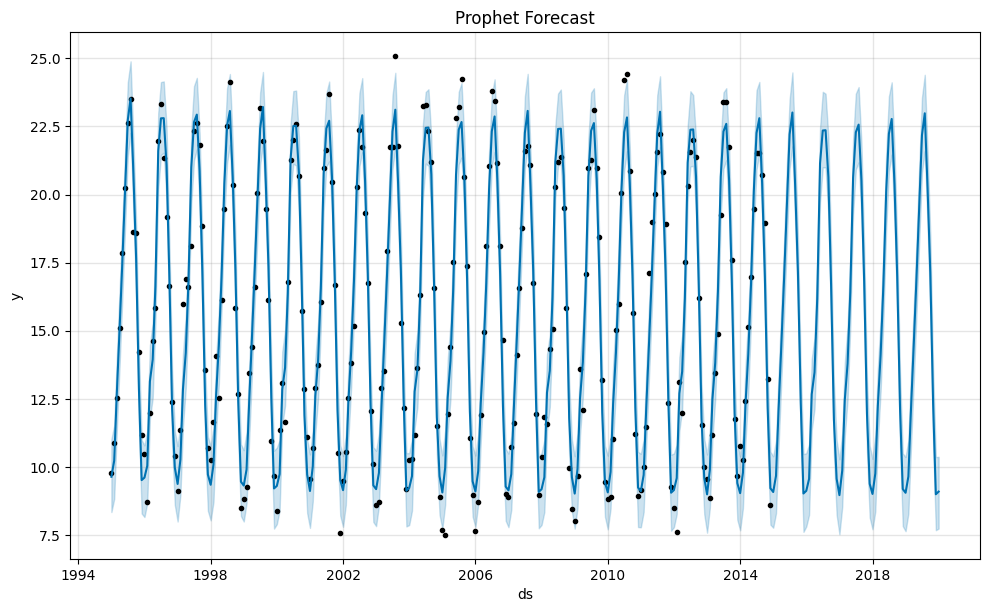

In [47]:
# Plot the forecast
fig1 = model.plot(forecast)
plt.title("Prophet Forecast")

Text(0.5, 1.02, 'Prophet Forecast Components')

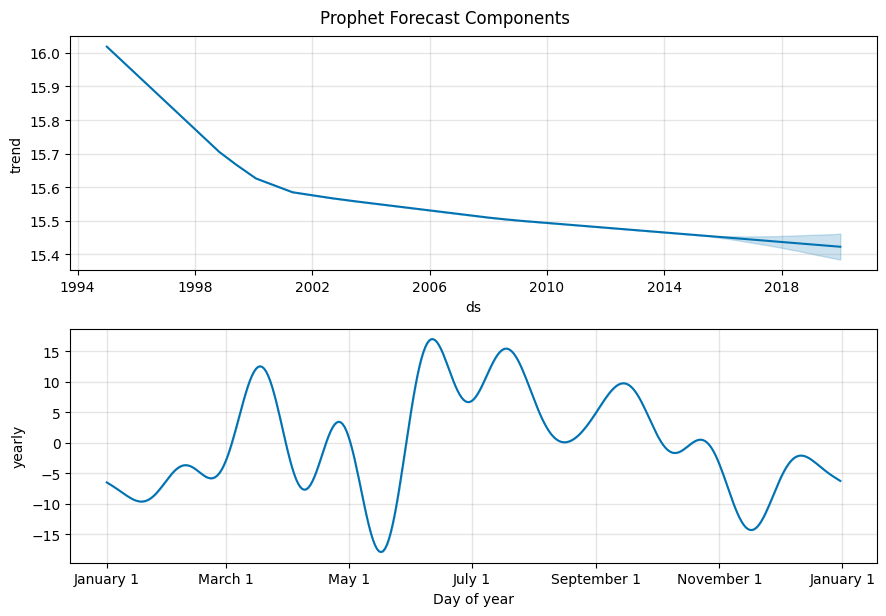

In [48]:
# Plot forecast components
fig2 = model.plot_components(forecast)
plt.suptitle("Prophet Forecast Components", y=1.02)

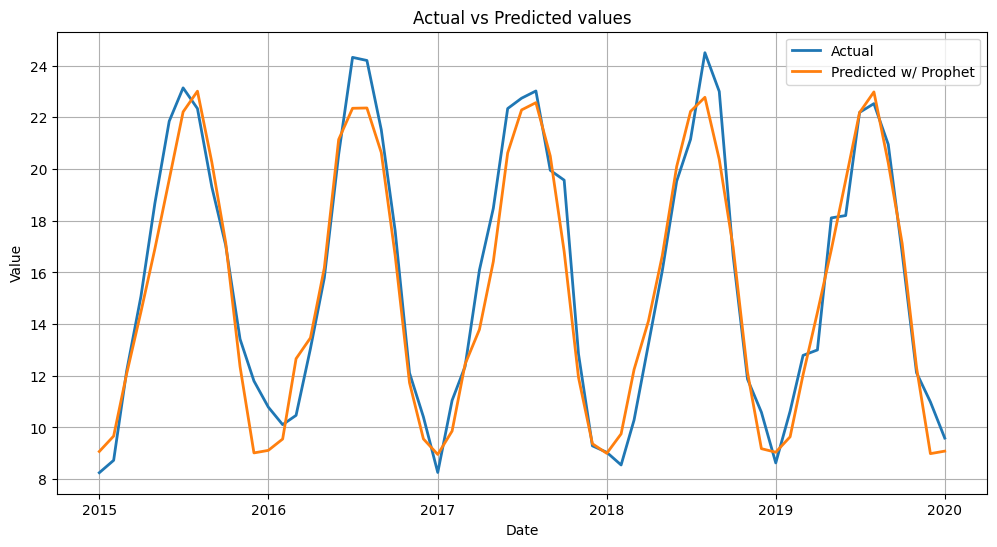

In [49]:
# Filter forecast to only the test dates
forecast_test = forecast.set_index('ds').loc[y_test.index]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, forecast_test['yhat'], label="Predicted w/ Prophet", linewidth=2)

plt.title("Actual vs Predicted values")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

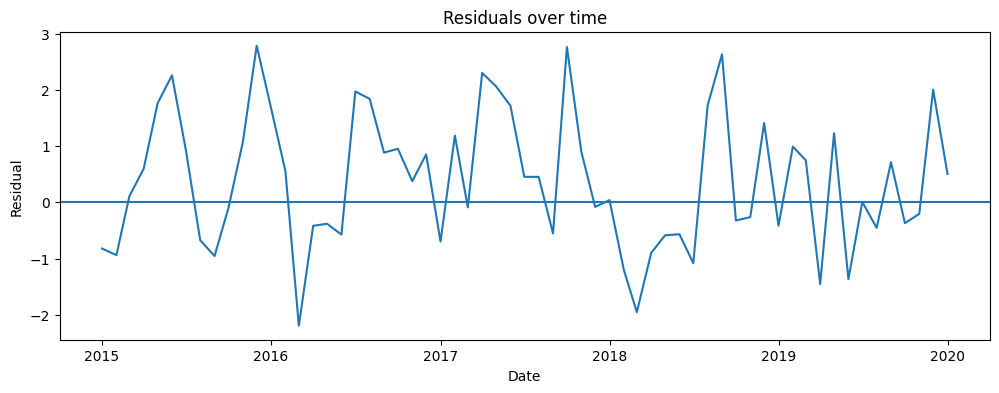

In [50]:
residuals = y_test - forecast_test['yhat']

plt.figure(figsize=(12, 4))
plt.plot(forecast_test.index, residuals)
plt.axhline(0)
plt.title("Residuals over time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

## Hyperparameter Tuning
In this section, we tune Prophet’s hyperparameters to identify the parameter combination that yields the best performance for our dataset. To achieve this, we use Prophet’s built-in diagnostic tools, **cross_validation** and **performance_metrics**.

The hyperparameters that we tune are:

* **changepoint_prior_scale**: This is probably the most impactful parameter. It determines the flexibility of the trend, and in particular how much the trend changes at the trend changepoints. If it is too small, the trend will be underfit and variance that should have been modeled with trend changes will instead end up being handled with the noise term. If it is too large, the trend will overfit and in the most extreme case the trend will capture yearly seasonality;

* **seasonality_prior_scale**: This parameter controls the flexibility of the seasonality. Similarly, a large value allows the seasonality to fit large fluctuations, a small value shrinks the magnitude of the seasonality;

* **seasonality_mode**: This parameters determines if the model should model an additive or multiplicative seasonality. Options are "additive" or "multiplicative";

* **yearly_seasonality**: Indicates whether yearly seasonality should be included in the model. Although the dataset exhibits yearly seasonality, we also tune this parameter to check whether disabling it might yield better results.

In [51]:
from prophet.diagnostics import performance_metrics
from prophet.diagnostics import cross_validation
import itertools

# Define the parameter grid
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    "seasonality_mode": ['additive', 'multiplicative']
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(data)  # Fit model with given params
    df_cv = cross_validation(m, initial="7304 days", horizon='1826 days', period= "30 days", parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
best_params = tuning_results.sort_values(by='rmse').iloc[0].to_dict()
print(best_params)


16:18:33 - cmdstanpy - INFO - Chain [1] start processing
16:18:33 - cmdstanpy - INFO - Chain [1] done processing
16:18:33 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
16:18:33 - cmdstanpy - INFO - Chain [1] start processing
16:18:34 - cmdstanpy - INFO - Chain [1] done processing
16:18:37 - cmdstanpy - INFO - Chain [1] start processing
16:18:37 - cmdstanpy - INFO - Chain [1] done processing
16:18:37 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
16:18:37 - cmdstanpy - INFO - Chain [1] start processing
16:18:37 - cmdstanpy - INFO - Chain [1] done processing
16:18:40 - cmdstanpy - INFO - Chain [1] start processing
16:18:40 - cmdstanpy - INFO - Chain [1] done processing
16:18:40 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
16:18:40 - c

{'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'additive', 'rmse': 1.205211255482128}


16:19:41 - cmdstanpy - INFO - Chain [1] start processing
16:19:41 - cmdstanpy - INFO - Chain [1] done processing


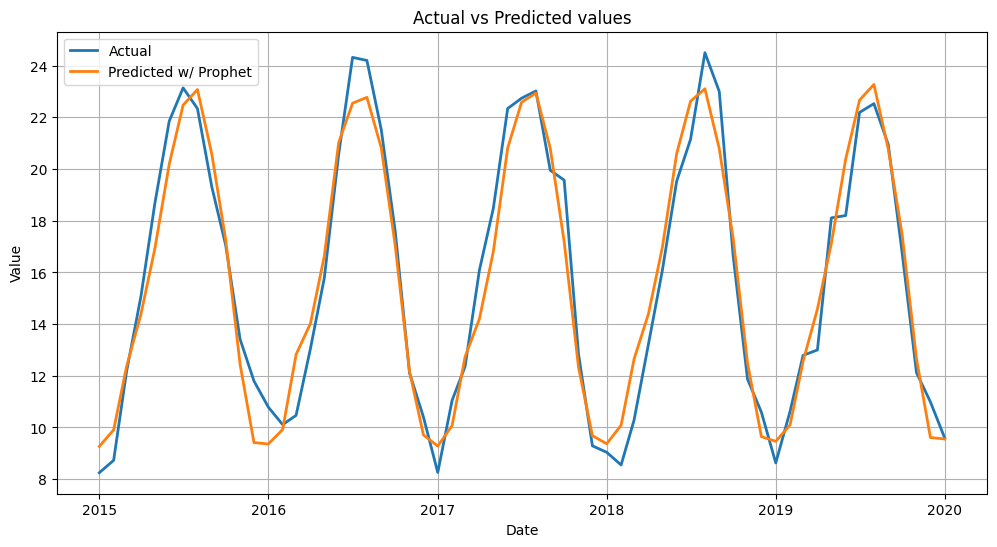

MAE: 1.0013350690441236
RMSE: 1.1907686679901193
Standard Deviation of Residuals: 1.1997197107137323


In [52]:
# Fit the model with the best parameters
model = Prophet(changepoint_prior_scale=best_params['changepoint_prior_scale'],
                seasonality_prior_scale=best_params['seasonality_prior_scale'],
                seasonality_mode=best_params['seasonality_mode'])
model.fit(train)
future = model.make_future_dataframe(periods=len(test), freq='MS')

forecast = model.predict(future)

# Filter forecast to only the test dates
forecast_test = forecast.set_index('ds').loc[y_test.index]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, forecast_test['yhat'], label="Predicted w/ Prophet", linewidth=2)

plt.title("Actual vs Predicted values")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()
evaluate(y_test, forecast['yhat'][-len(test):])

## Modelling with Rolling window
In this section, we take the hyperparameters obtained from the previous step and apply them to a rolling-window forecasting setup. Our rolling window uses a training period of 9 years followed by a 1-year forecasting horizon.

In [53]:
window_size = 96  # 8 years
forecast_horizon = 24  # 2-year ahead

preds = []
actuals = []
dates = []

lb_results = []

for start in range(0, len(data) - window_size - forecast_horizon + 1, forecast_horizon):

    # Training and test windows
    train_window = data.iloc[start:start + window_size]
    test_window = data.iloc[start + window_size:start + window_size + forecast_horizon]

    # Initialize Prophet model with best params
    model = Prophet(
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=best_params['seasonality_mode']
    )

    # Fit model
    model.fit(train_window)

    # Forecast one full horizon
    future = model.make_future_dataframe(periods=forecast_horizon, freq='MS')
    forecast = model.predict(future)

    # Extract forecast matching the test-window dates
    forecast_window = (
        forecast.set_index('ds')
                .loc[test_window['ds'].values]  # aligned on timestamp
    )

    # Store values
    preds.extend(forecast_window['yhat'].values)
    actuals.extend(test_window['y'].values)
    dates.extend(test_window['ds'].values)

    # Residuals for this window
    residuals = test_window['y'].values - forecast_window['yhat'].values

    # Ljung–Box at seasonal lag
    lb = acorr_ljungbox(
        residuals,
        lags=[12],
        return_df=True
    )

    lb_results.append({
        'ds': test_window['ds'].iloc[-1],   # end of forecast window
        'lb_stat': lb['lb_stat'].iloc[0],
        'p_value': lb['lb_pvalue'].iloc[0]
    })

evaluate(actuals, preds)

#DataFrame for plotting
results_df = pd.DataFrame({
    'ds': dates,
    'actual': actuals,
    'predicted': preds
})

16:19:41 - cmdstanpy - INFO - Chain [1] start processing
16:19:42 - cmdstanpy - INFO - Chain [1] done processing
16:19:42 - cmdstanpy - INFO - Chain [1] start processing
16:19:43 - cmdstanpy - INFO - Chain [1] done processing
16:19:43 - cmdstanpy - INFO - Chain [1] start processing
16:19:44 - cmdstanpy - INFO - Chain [1] done processing
16:19:44 - cmdstanpy - INFO - Chain [1] start processing
16:19:44 - cmdstanpy - INFO - Chain [1] done processing
16:19:45 - cmdstanpy - INFO - Chain [1] start processing
16:19:45 - cmdstanpy - INFO - Chain [1] done processing
16:19:45 - cmdstanpy - INFO - Chain [1] start processing
16:19:46 - cmdstanpy - INFO - Chain [1] done processing
16:19:46 - cmdstanpy - INFO - Chain [1] start processing
16:19:47 - cmdstanpy - INFO - Chain [1] done processing
16:19:47 - cmdstanpy - INFO - Chain [1] start processing
16:19:48 - cmdstanpy - INFO - Chain [1] done processing


MAE: 1.3534225033430263
RMSE: 1.654143220631533
Standard Deviation of Residuals: 1.657410801970706


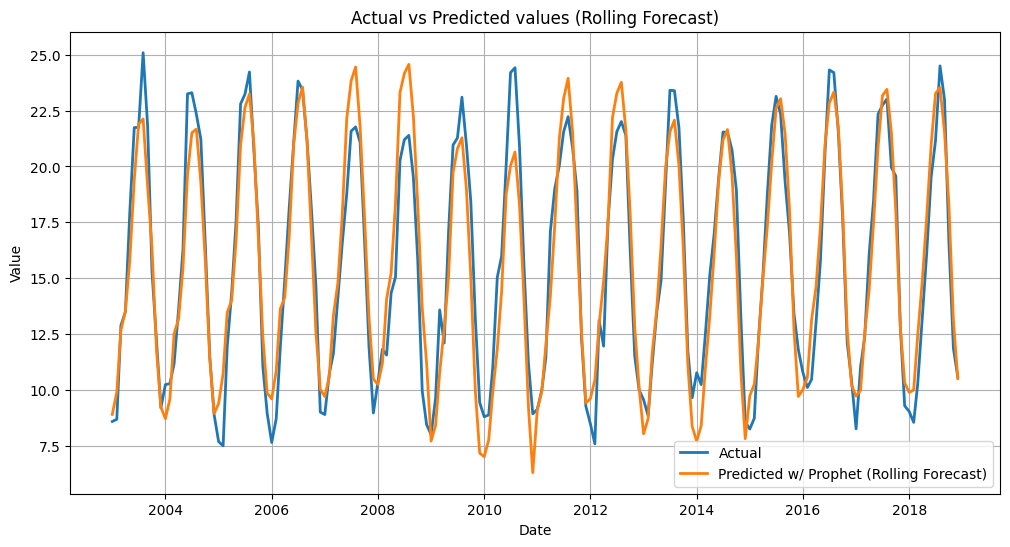

In [54]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(results_df["ds"], results_df["actual"], label="Actual", linewidth=2)
plt.plot(results_df["ds"], results_df["predicted"], label="Predicted w/ Prophet (Rolling Forecast)", linewidth=2)
plt.title("Actual vs Predicted values (Rolling Forecast)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

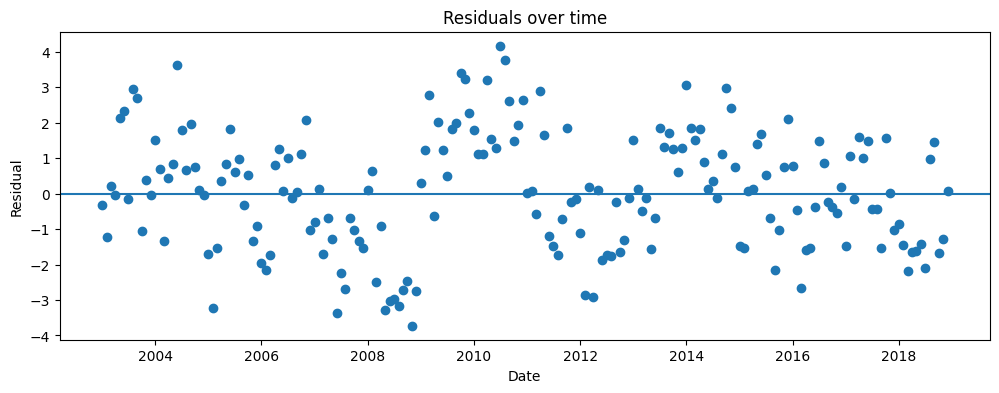

In [55]:
residuals = np.array(actuals) - np.array(preds)

plt.figure(figsize=(12, 4))
plt.scatter(results_df["ds"], residuals)
plt.axhline(0)
plt.title("Residuals over time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

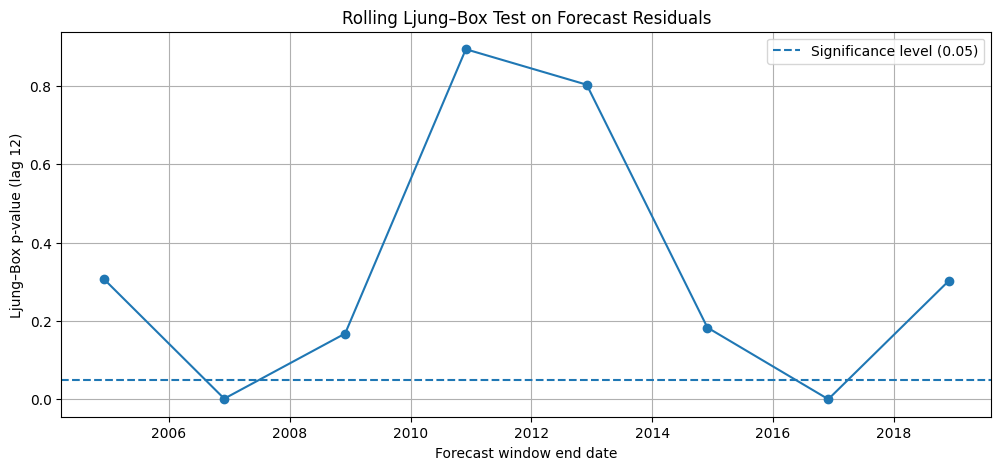

In [56]:
lb_df = pd.DataFrame(lb_results)

plot_lb_test(lb_df, rolling_window=True)

## ACF and PACF computation
In this section we compute the ACF and the PACF of the residuals to diagnose if the model is working well or not.

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Initialize Prophet model with best params
model = Prophet(
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_mode=best_params['seasonality_mode']
)
model.fit(data)

# Cross-validated predictions (out-of-sample forecasts to avoid optimistic diagnostics.)
df_cv = cross_validation(
    model,
    horizon="365 days",
    period="30 days",
    initial="7304 days"
)

# Residuals
residuals = df_cv['y'] - df_cv['yhat']

16:19:48 - cmdstanpy - INFO - Chain [1] start processing
16:19:48 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/49 [00:00<?, ?it/s]16:19:49 - cmdstanpy - INFO - Chain [1] start processing
16:19:49 - cmdstanpy - INFO - Chain [1] done processing
  2%|▏         | 1/49 [00:00<00:08,  5.39it/s]16:19:49 - cmdstanpy - INFO - Chain [1] start processing
16:19:49 - cmdstanpy - INFO - Chain [1] done processing
  4%|▍         | 2/49 [00:00<00:08,  5.33it/s]16:19:49 - cmdstanpy - INFO - Chain [1] start processing
16:19:49 - cmdstanpy - INFO - Chain [1] done processing
  6%|▌         | 3/49 [00:00<00:08,  5.26it/s]16:19:49 - cmdstanpy - INFO - Chain [1] start processing
16:19:49 - cmdstanpy - INFO - Chain [1] done processing
  8%|▊         | 4/49 [00:00<00:08,  5.27it/s]16:19:49 - cmdstanpy - INFO - Chain [1] start processing
16:19:49 - cmdstanpy - INFO - Chain [1] done processing
 10%|█         | 5/49 [00:00<00:08,  5.19it/s]16:19:50 - cmdstanpy - INFO - Chain [1] start processi

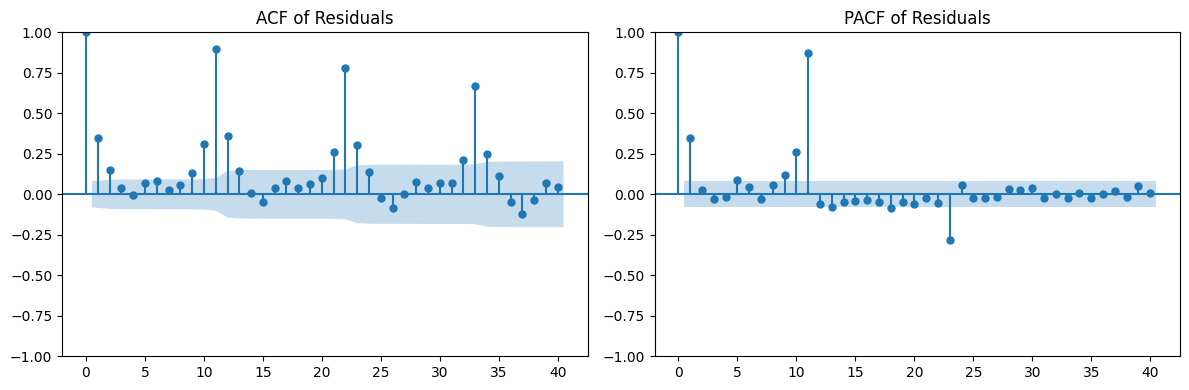

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(residuals, lags=40, ax=axes[0])
axes[0].set_title("ACF of Residuals")

plot_pacf(residuals, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Residuals")

plt.tight_layout()
plt.show()

Given the plots of the ACF and PACF, we can surmise these things:
* Most autocorrelation values lie within the confidence bounds;
* Most autocorrelation values fluctuate around zero;
* There are clear significant spikes at lags 12, 24, etc... for the ACF and clear spikes for lag 12 for the PACF.

Based on the above, we conclude that the model successfully captures the overall trend and that there is no strong short-term autoregressive structure remaining in the residuals. However, the model does not fully capture the annual seasonal patterns, despite yearly seasonality being explicitly enabled. This behavior is likely due to the dataset showing cyclostationarity at lag 12.

Since Prophet is specifically designed to model seasonal effects directly, we avoid applying seasonal differencing at lag 12. Altering the dataset is not recommended for Prophet, as it would remove seasonal information that the model relies on for forecasting. Instead, we try to solve this issue by adjusting the model’s seasonal parameters to better capture the underlying annual cycle.


16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/49 [00:00<?, ?it/s]16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
  2%|▏         | 1/49 [00:00<00:13,  3.68it/s]16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
  4%|▍         | 2/49 [00:00<00:11,  4.06it/s]16:19:59 - cmdstanpy - INFO - Chain [1] start processing
16:19:59 - cmdstanpy - INFO - Chain [1] done processing
  6%|▌         | 3/49 [00:00<00:11,  4.05it/s]16:20:00 - cmdstanpy - INFO - Chain [1] start processing
16:20:00 - cmdstanpy - INFO - Chain [1] done processing
  8%|▊         | 4/49 [00:00<00:11,  4.05it/s]16:20:00 - cmdstanpy - INFO - Chain [1] start processing
16:20:00 - cmdstanpy - INFO - Chain [1] done processing
 10%|█         | 5/49 [00:01<00:10,  4.10it/s]16:20:00 - cmdstanpy - INFO - Chain [1] start processi

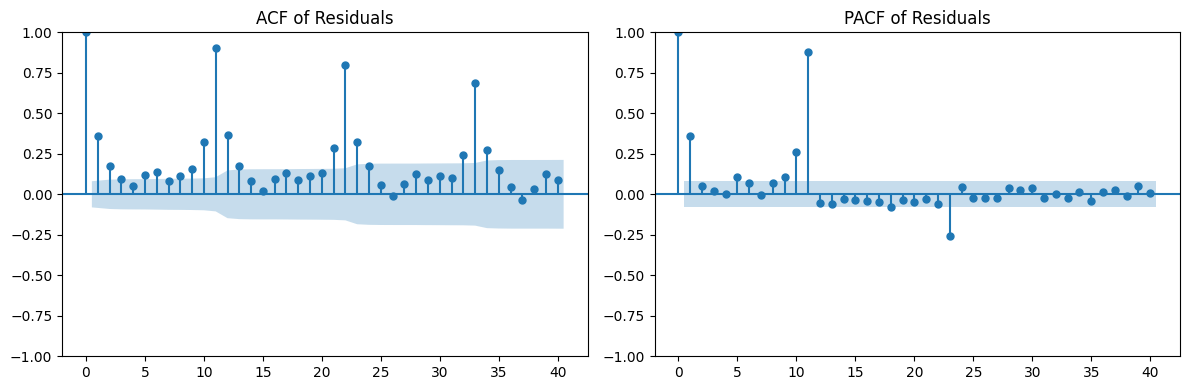

In [59]:
model = Prophet(
    yearly_seasonality=False,
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_mode=best_params['seasonality_mode']
)

model.add_seasonality(
    name='yearly',
    period=365.25,
    fourier_order=35  # increase flexibility
)

model.fit(data)

# Cross-validated predictions (out-of-sample forecasts to avoid optimistic diagnostics.)
df_cv = cross_validation(
    model,
    horizon="365 days",
    period="30 days",
    initial="7304 days"
)

# Residuals
residuals = df_cv['y'] - df_cv['yhat']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(residuals, lags=40, ax=axes[0])
axes[0].set_title("ACF of Residuals")

plot_pacf(residuals, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Residuals")

plt.tight_layout()
plt.show()

Increasing the Fourier order of the yearly seasonal component does not eliminate the residual autocorrelation at lag 12. This indicates the presence of time-varying annual seasonality (cyclostationarity), which cannot be fully captured by Prophet’s global seasonal formulation (Prophet assumes seasonality is globally consistent overtime). Nevertheless, the model adequately captures the overall trend and short-term dynamics, and the rolling-window forecasting strategy helps mitigate the impact of this remaining seasonal structure.
